# SmartPark Occupancy Forecasting — Master Technical Report

Notebook ini merupakan **laporan teknis utama** untuk proyek prediksi tingkat keterisian parkir. Laporan disusun untuk menunjukkan proses kerja secara runtut mulai dari pemahaman data, pembentukan variabel `occupancy_rate`, eksplorasi pola, pemodelan prediktif, evaluasi, hingga persiapan penggunaan model pada aplikasi.

Fokus proyek adalah **time-series forecasting** terhadap `occupancy_rate` 30 menit ke depan. Nilai `occupancy_rate` merupakan proporsi area parkir yang terisi pada rentang 0 sampai 1. Dengan definisi ini, hasil prediksi dapat langsung dikonversi menjadi persentase keterisian parkir yang mudah dipahami oleh pengelola operasional.

Laporan ini ditulis dengan gaya dokumentasi profesional agar dapat dibaca oleh praktisi, asesor, dan anggota tim lintas peran. Struktur notebook dibuat berurutan: **Data Science**, **Pemodelan Prediktif**, **Evaluasi dan Backtesting**, kemudian **Inference dan Deployment Preparation**.

## Executive Summary

Tujuan utama proyek ini adalah membangun pipeline prediksi keterisian parkir yang dapat membantu pengelola mengambil keputusan operasional, misalnya mengantisipasi kepadatan, mengarahkan kendaraan ke area alternatif, atau menyiapkan tindakan saat kapasitas mendekati penuh.

Secara ringkas, notebook ini mencakup empat proses utama:

1. **Data Science** — memahami struktur data, melakukan data wrangling, membentuk time-series `occupancy_rate`, melakukan EDA, dan merancang fitur prediktif.
2. **Pemodelan Prediktif** — menyiapkan sequence time-series, melakukan scaling, membangun model berbasis TensorFlow, serta melatih beberapa kandidat model.
3. **Evaluasi dan Validasi** — mengembalikan prediksi ke skala asli, menghitung metrik performa, membandingkan model dengan baseline, dan melakukan backtesting.
4. **Persiapan Implementasi** — menyimpan model, scaler, feature list, serta menyiapkan contoh inference dan API untuk integrasi aplikasi.

Metrik utama yang digunakan dalam laporan adalah **MAE pada skala asli `occupancy_rate`**, bukan MAE pada target yang telah distandardisasi. Dengan demikian, hasil evaluasi dapat langsung dibaca sebagai rata-rata kesalahan prediksi dalam proporsi keterisian parkir.

## Struktur Laporan dan Pembagian Tanggung Jawab

Notebook ini disusun dengan urutan **Data Science → Pemodelan Prediktif → Evaluasi → Deployment Preparation**. Urutan tersebut dipilih agar pembaca memahami terlebih dahulu kualitas dan karakter data sebelum melihat desain model dan hasil evaluasinya.

| Bagian | Fokus | Pemilik Utama | Output yang Diharapkan |
|---|---|---|---|
| Bagian 1 | Data understanding, data wrangling, EDA, data dictionary, dan feature engineering | Data Science | Dataset time-series `occupancy_rate` yang siap digunakan untuk modeling |
| Bagian 2 | Sequence preparation, arsitektur model, training, custom layer/loss/callback, dan export model | AI Engineer / Tim Pemodelan / Tim Pemodelan | Model forecasting yang dapat dilatih, dievaluasi, dan digunakan untuk inference |
| Bagian 3 | Evaluasi metrik, weighted ensemble, offline backtesting, dan bootstrapping | Data Science + Tim Pemodelan | Bukti performa model pada skala asli `occupancy_rate` |
| Bagian 4 | Inference, rekomendasi operasional, penyimpanan artefak, dan persiapan API | AI Engineer / Tim Pemodelan + Backend | Artefak model dan alur inference yang siap diintegrasikan ke aplikasi |

Catatan penting: A/B testing pada notebook ini ditempatkan sebagai **evaluasi Data Science** karena tujuannya adalah menguji apakah model forecasting memberikan nilai tambah dibandingkan baseline sederhana pada data historis.

## Definisi Masalah dan Target Prediksi

Masalah yang diselesaikan adalah **forecasting tingkat keterisian parkir 30 menit ke depan**. Data mentah memiliki kolom `occupancy` bernilai 0 atau 1 karena merepresentasikan status setiap slot/patch parkir pada waktu tertentu. Nilai tersebut tidak langsung digunakan sebagai target model.

Tahap preprocessing mengagregasi data mentah menjadi `occupancy_rate`:

```text
occupancy_rate = jumlah slot terisi / total slot yang teramati pada timestamp tertentu
```

Target model kemudian didefinisikan sebagai:

```text
target_occ = occupancy_rate pada 30 menit berikutnya
```

Dengan interval data 10 menit, horizon 30 menit direpresentasikan dengan `shift(-3)`. Oleh karena itu, notebook ini tidak membangun model klasifikasi kosong/terisi, melainkan model regresi time-series untuk memprediksi nilai kontinu pada rentang 0 sampai 1.

## Pertanyaan Bisnis dan Kriteria Keberhasilan

Pertanyaan bisnis utama:

> Bagaimana pola tingkat keterisian parkir berdasarkan waktu, cuaca, dan hari, serta seberapa baik model dapat memprediksi `occupancy_rate` 30 menit ke depan dibandingkan baseline sederhana?

Kriteria keberhasilan teknis:

| Area | Kriteria |
|---|---|
| Kualitas data | Data bersih, timestamp valid, missing value tertangani, dan time-series tersusun konsisten |
| EDA | Setiap visualisasi memiliki interpretasi yang menjelaskan pola atau risiko data |
| Modeling | Model dilatih menggunakan split berbasis waktu tanpa pengacakan test set |
| Evaluasi | MAE, RMSE, R², dan akurasi ±5% dihitung pada skala asli `occupancy_rate` |
| Anti-leakage | Scaler dan proses transformasi tidak menggunakan informasi dari validation/test untuk fitting |
| Backtesting | Model dibandingkan dengan naive persistence baseline pada test set historis |
| Deployment | Model, scaler, dan daftar fitur diekspor agar dapat digunakan kembali oleh API/inference pipeline |

## Panduan Membaca Notebook

Beberapa istilah penting yang digunakan secara konsisten dalam laporan:

- `occupancy`: status slot/patch pada data mentah, bernilai 0 atau 1.
- `occupancy_rate`: proporsi keterisian parkir setelah agregasi per timestamp.
- `target_occ`: `occupancy_rate` pada horizon prediksi 30 menit ke depan.
- `WINDOW_SIZE`: jumlah observasi historis yang digunakan sebagai input model.
- `TARGET_HORIZON`: jarak prediksi ke depan dalam satuan interval 10 menit.
- `MAE original scale`: MAE setelah prediksi dikembalikan dari hasil standardisasi ke skala asli 0 sampai 1.

Pembaca disarankan memeriksa hasil akhir evaluasi pada bagian backtesting dan final summary, karena bagian tersebut menunjukkan apakah model benar-benar memberi nilai tambah dibanding baseline sederhana.

## Bagian 0 — Environment dan Konfigurasi Dasar


In [ ]:
# Bagian ini memuat dependensi utama yang digunakan sepanjang notebook.
# Import dilakukan di awal agar seluruh fungsi analisis, visualisasi, modeling,
# dan evaluasi memiliki lingkungan kerja yang konsisten.

# -----------------------------------------------------------------------------
# 1. Environment Setup
# -----------------------------------------------------------------------------
# Cell ini menyiapkan package utama yang dibutuhkan notebook.
# Jika notebook dijalankan di Google Colab, instalasi dilakukan melalui pip.
# Jika semua package sudah tersedia di environment lokal, cell ini dapat dilewati.

# Install dependencies when running in Google Colab.
# The cell is safe to skip if all packages are already available.
!pip install -q tensorflow numpy scikit-learn pandas matplotlib scipy fastapi uvicorn nest-asyncio pyngrok statsmodels

import os
import re
import json
import gc
import pickle
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path('/content/smartpark_outputs')
LOG_DIR = Path('/content/smartpark_logs')
for directory in [OUTPUT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Environment is ready.')
print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))


Environment is ready.
TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Bagian 1 — Data Science: Data Understanding, EDA, dan Persiapan Modeling

Bagian Data Science berfokus pada proses dari data mentah sampai data siap digunakan untuk modeling. Tahapan ini mencakup pengumpulan data, pemahaman struktur data, data wrangling, cleaning, EDA, explanatory analysis, data dictionary, dan feature engineering.

Output utama dari bagian ini adalah dataset time-series yang bersih, terdokumentasi, dan memiliki fitur yang relevan untuk prediksi `occupancy_rate` 30 menit ke depan.

### Interpretasi Hasil Data Understanding

Berdasarkan eksekusi preprocessing, dataset mentah berisi **157,549 baris** dan setelah diagregasi menjadi time-series 10 menit menghasilkan **32,267 baris bersih** dengan **37 kolom**. Rentang waktu data yang digunakan adalah **2015-07-03 16:00:00 sampai 2016-02-12 17:40:00**.

Hal penting yang perlu dicatat adalah proporsi timestamp kosong sebelum interpolasi mencapai sekitar **96.44%** setelah resampling 10 menit. Ini bukan berarti data mentah rusak, tetapi menunjukkan bahwa observasi asli tidak tersedia pada setiap interval 10 menit secara kontinu. Karena itu, keputusan interpolasi harus dijelaskan di laporan sebagai strategi pembentukan time-series reguler, bukan sekadar cleaning biasa.

Rata-rata `occupancy_rate` adalah **0.305** atau sekitar **30.5%**, dengan median **0.279**. Artinya, secara umum parkir lebih sering berada pada kondisi rendah sampai sedang, bukan selalu penuh. Ini penting untuk interpretasi model karena target ekstrem mendekati 1 relatif lebih jarang.


## 1.1 Rumusan Pertanyaan Bisnis

Agar analisis dan pemodelan memiliki arah yang terukur, proyek ini dirumuskan melalui pertanyaan bisnis berikut:

> Bagaimana pola tingkat keterisian parkir berdasarkan waktu, cuaca, hari, dan riwayat okupansi sebelumnya, serta seberapa baik model dapat memprediksi `occupancy_rate` 30 menit ke depan dibandingkan baseline sederhana?

Pertanyaan tersebut diterjemahkan menjadi beberapa sasaran teknis:

1. Membentuk variabel `occupancy_rate` dari data status slot/patch parkir.
2. Menganalisis pola keterisian berdasarkan jam, hari, cuaca, dan dinamika historis.
3. Membangun fitur time-series yang relevan untuk prediksi jangka pendek.
4. Melatih model forecasting dan mengevaluasinya pada test set berbasis urutan waktu.
5. Membandingkan model terhadap naive persistence baseline melalui offline backtesting.

## 1.2 Data Acquisition

Pipeline ini menggunakan CSV `CNRParkEXT (1).csv`. Jika file berada di direktori Colab `/content`, notebook akan mendeteksi file tersebut secara otomatis. Jika file belum tersedia, unggah file CSV terlebih dahulu.


Tahap ini memastikan notebook dapat dijalankan ulang pada lingkungan kerja yang berbeda. Dataset dibaca dari file CSV utama. Jika notebook dijalankan di Google Colab, path file dapat disesuaikan tanpa mengubah logika analisis.

Output yang diharapkan dari tahap ini adalah dataframe mentah yang belum diubah, sehingga proses penilaian kualitas data tetap transparan.

In [ ]:
# Membaca dataset utama.
# Dataset diperlakukan sebagai data mentah; perubahan struktur data dilakukan
# pada tahap wrangling agar setiap transformasi dapat ditelusuri dengan jelas.

# -----------------------------------------------------------------------------
# 2. Data Acquisition
# -----------------------------------------------------------------------------


CSV_PATH = Path('/content/CNRParkEXT.csv')

print(f'CSV file used: {CSV_PATH}')
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print('Raw dataset shape:', df_raw.shape)
display(df_raw.head())


CSV file used: /content/CNRParkEXT.csv
Raw dataset shape: (157549, 12)


,camera,datetime,day,hour,image_url,minute,month,occupancy,slot_id,weather,year,occupant_changed
0,A,20150703_0805,3,8,CNRPark/A/free/20150703_0805_1.jpg,5,7,0,1,S,2015,NaN
1,A,20150703_0810,3,8,CNRPark/A/free/20150703_0810_1.jpg,10,7,0,1,S,2015,NaN
2,A,20150703_0815,3,8,CNRPark/A/busy/20150703_0815_1.jpg,15,7,1,1,S,2015,0.0
3,A,20150703_0820,3,8,CNRPark/A/busy/20150703_0820_1.jpg,20,7,1,1,S,2015,0.0
4,A,20150703_0825,3,8,CNRPark/A/busy/20150703_0825_1.jpg,25,7,1,1,S,2015,0.0


## 1.3 Data Understanding dan Initial Assessment

Tahap ini memeriksa struktur kolom, tipe data, missing values, distribusi label okupansi, dan distribusi cuaca sebelum transformasi time-series.


In [ ]:
# -----------------------------------------------------------------------------
# 3. Data Understanding and Initial Assessment
# -----------------------------------------------------------------------------
# Cell ini memeriksa kondisi awal dataset sebelum transformasi time-series.
# Pemeriksaan dilakukan pada empat aspek utama:
# - struktur kolom dan tipe data;
# - jumlah dan persentase missing values;
# - distribusi label occupancy;
# - distribusi kode cuaca.
#
# Validasi awal ini penting agar kesalahan format data dapat ditemukan sebelum
# proses preprocessing, feature engineering, dan training model dijalankan.

print('Column overview:')
display(pd.DataFrame({
    'column': df_raw.columns,
    'dtype': [df_raw[c].dtype for c in df_raw.columns],
    'missing_count': [df_raw[c].isna().sum() for c in df_raw.columns],
    'missing_pct': [df_raw[c].isna().mean() * 100 for c in df_raw.columns]
}))

required_columns = {'datetime', 'weather', 'occupancy'}
missing_required = required_columns.difference(df_raw.columns)
if missing_required:
    raise ValueError(f'Kolom wajib tidak ditemukan: {missing_required}')

print('Occupancy label distribution:')
display(df_raw['occupancy'].value_counts(dropna=False).rename_axis('occupancy').reset_index(name='count'))

print('Weather code distribution:')
display(df_raw['weather'].value_counts(dropna=False).rename_axis('weather_code').reset_index(name='count'))


Column overview:


,column,dtype,missing_count,missing_pct
0,camera,object,0,0.000000
1,datetime,object,0,0.000000
2,day,int64,0,0.000000
3,hour,int64,0,0.000000
4,image_url,object,0,0.000000
5,minute,int64,0,0.000000
6,month,int64,0,0.000000
7,occupancy,int64,0,0.000000
8,slot_id,int64,0,0.000000
9,weather,object,0,0.000000


Occupancy label distribution:


,occupancy,count
0,1,87683
1,0,69866


Weather code distribution:


,weather_code,count
0,S,75762
1,O,44243
2,R,37544


## 1.4 Data Wrangling dan Pembentukan Time-Series

Bagian ini membentuk data time-series yang digunakan pada pipeline utama. Preprocessing dibuat konsisten dengan kebutuhan modeling dan inference, yaitu menggunakan interval observasi 10 menit dan target `occupancy_rate` 30 menit ke depan.

Tahapan yang dilakukan:

- Parsing timestamp dari kolom `datetime`.
- Mapping kode cuaca `S`, `C`, dan `R` menjadi `SUNNY`, `OVERCAST`, dan `RAINY`.
- Agregasi data patch-level menjadi `occupancy_rate` per timestamp.
- Resampling ke interval 10 menit agar data memiliki grid waktu yang konsisten.
- Interpolasi nilai `occupancy_rate` dan forward/backward fill pada cuaca.
- Pembentukan fitur temporal, lag, rolling statistics, momentum, acceleration, dan EMA.

Catatan metodologis: resampling dan interpolasi digunakan untuk menstandarkan data ke format time-series yang konsisten bagi proses modeling dan inference. Keterbatasan akibat ketidaklengkapan observasi waktu dijelaskan pada bagian interpretasi dan kesimpulan.

Tahap wrangling merupakan jembatan antara data mentah dan data modeling. Pada data mentah, kolom `occupancy` bernilai 0 atau 1 pada level slot/patch. Nilai tersebut tidak langsung dijadikan target model. Nilai 0/1 terlebih dahulu diagregasi per timestamp menjadi `occupancy_rate`, yaitu proporsi slot/patch yang terisi pada waktu tertentu.

Definisi ini penting agar tidak terjadi salah tafsir. Proyek ini bukan klasifikasi slot kosong/terisi, melainkan **forecasting tingkat keterisian parkir**. Target yang diprediksi adalah `occupancy_rate` pada 30 menit ke depan.

In [ ]:
# Membentuk time-series occupancy_rate.
# Kolom occupancy bernilai 0/1 pada level slot/patch. Nilai tersebut diagregasi
# per timestamp untuk memperoleh proporsi keterisian parkir secara keseluruhan.
#
# Pipeline utama menggunakan resampling 10 menit dan interpolasi untuk membentuk
# grid waktu yang konsisten. Pendekatan ini dipertahankan agar preprocessing
# training, evaluasi, dan inference tetap selaras.

# -----------------------------------------------------------------------------
# 4. Preprocessing Time-Series
# -----------------------------------------------------------------------------
# Data mentah berada pada level patch atau slot pengamatan.
# Agar dapat digunakan oleh model forecasting, data diagregasi menjadi satu baris
# per timestamp dengan target berupa tingkat okupansi parkir.
#
# Prinsip utama preprocessing:
# - timestamp diparsing secara robust dari beberapa format tanggal/jam;
# - weather distandarkan menjadi kategori yang konsisten;
# - occupancy_rate dihitung sebagai occupied_slots / total_patches;
# - data di-resample ke interval 10 menit;
# - missing value occupancy diinterpolasi dan weather diisi forward/backward;
# - fitur temporal, lag, rolling statistics, momentum, acceleration, dan EMA dibuat.

def parse_dt(val):
    if not isinstance(val, str):
        return pd.NaT

    m = re.match(r'(\d{4}-\d{2}-\d{2})_(\d{2})[\.:](\d{2})', val)
    if m:
        try:
            return pd.to_datetime(
                f'{m.group(1)} {m.group(2)} {m.group(3)}',
                format='%Y-%m-%d %H %M'
            )
        except Exception:
            pass

    m2 = re.match(r'(\d{8})_(\d{2})(\d{2})', val)
    if m2:
        try:
            return pd.to_datetime(
                f'{m2.group(1)} {m2.group(2)} {m2.group(3)}',
                format='%Y%m%d %H %M'
            )
        except Exception:
            pass

    return pd.to_datetime(val, errors='coerce')


df = df_raw.copy()
df['timestamp'] = df['datetime'].apply(parse_dt)
df['weather'] = df['weather'].map({'S': 'SUNNY', 'C': 'OVERCAST', 'R': 'RAINY'}).fillna('UNKNOWN')

invalid_timestamp_count = df['timestamp'].isna().sum()
print('Invalid timestamp rows:', invalid_timestamp_count)

# Aggregate patch-level records into timestamp-level occupancy rate.
df_ts = (
    df.dropna(subset=['timestamp'])
    .groupby('timestamp')
    .agg(
        occupied_slots=('occupancy', 'sum'),
        total_patches=('occupancy', 'count'),
        weather=('weather', lambda x: x.mode().iloc[0] if not x.mode().empty else 'UNKNOWN')
    )
    .reset_index()
)

df_ts['occupancy_rate'] = (df_ts['occupied_slots'] / df_ts['total_patches']).clip(0, 1)
df_ts = df_ts.set_index('timestamp')

# Resample to uniform 10-minute time steps.
df_uni = df_ts.resample('10min').agg({
    'weather': lambda x: x.mode().iloc[0] if len(x.dropna()) else np.nan,
    'occupancy_rate': 'mean'
}).reset_index()

df_uni['occupancy_rate'] = df_uni['occupancy_rate'].interpolate(limit_direction='both').clip(0, 1)
df_uni['weather'] = df_uni['weather'].ffill().bfill().fillna('UNKNOWN')

# Calendar features.
df_uni['hour'] = df_uni['timestamp'].dt.hour
df_uni['day_of_week'] = df_uni['timestamp'].dt.dayofweek
df_uni['is_weekend'] = (df_uni['day_of_week'] >= 5).astype(int)
df_uni['month'] = df_uni['timestamp'].dt.month

# Encoded and cyclical features.
weather_map = {'SUNNY': 0, 'OVERCAST': 1, 'RAINY': 2, 'UNKNOWN': 0}
df_uni['weather_encoded'] = df_uni['weather'].map(weather_map).fillna(0).astype(int)
df_uni['hour_sin'] = np.sin(2 * np.pi * df_uni['hour'] / 24)
df_uni['hour_cos'] = np.cos(2 * np.pi * df_uni['hour'] / 24)
df_uni['dow_sin'] = np.sin(2 * np.pi * df_uni['day_of_week'] / 7)
df_uni['dow_cos'] = np.cos(2 * np.pi * df_uni['day_of_week'] / 7)

# Operational time flags.
df_uni['is_morning_peak'] = df_uni['hour'].between(8, 11).astype(int)
df_uni['is_evening_peak'] = df_uni['hour'].between(16, 19).astype(int)
df_uni['is_rush_hour'] = df_uni['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

# Lag features.
for lag in [1, 2, 3, 6, 12, 24, 48]:
    df_uni[f'lag_{lag}'] = df_uni['occupancy_rate'].shift(lag)

# Rolling features.
for window in [3, 6, 12, 24, 48]:
    df_uni[f'roll_mean_{window}'] = df_uni['occupancy_rate'].rolling(window, min_periods=1).mean()
    df_uni[f'roll_std_{window}'] = df_uni['occupancy_rate'].rolling(window, min_periods=1).std().fillna(0)

# Dynamic features.
df_uni['momentum'] = df_uni['occupancy_rate'].diff().fillna(0)
df_uni['acceleration'] = df_uni['momentum'].diff().fillna(0)
df_uni['ema_01'] = df_uni['occupancy_rate'].ewm(alpha=0.1).mean()
df_uni['ema_03'] = df_uni['occupancy_rate'].ewm(alpha=0.3).mean()

TARGET_HORIZON = 3  # 3 x 10 minutes = 30 minutes ahead
df_uni['target_occ'] = df_uni['occupancy_rate'].shift(-TARGET_HORIZON)

FEATURE_COLS = [
    'occupancy_rate', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'weather_encoded', 'is_morning_peak', 'is_evening_peak', 'is_rush_hour',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48',
    'roll_mean_3', 'roll_std_3', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12',
    'momentum', 'acceleration', 'ema_01', 'ema_03'
]

df_clean = df_uni.dropna(subset=FEATURE_COLS + ['target_occ']).reset_index(drop=True)

print('Uniform time-series shape:', df_uni.shape)
print('Clean dataset shape:', df_clean.shape)
print('Number of model features:', len(FEATURE_COLS))
print('Forecast horizon:', TARGET_HORIZON * 10, 'minutes')
display(df_clean.head())


Invalid timestamp rows: 0
Uniform time-series shape: (32318, 37)
Clean dataset shape: (32267, 37)
Number of model features: 27
Forecast horizon: 30 minutes


,timestamp,weather,occupancy_rate,hour,day_of_week,is_weekend,month,weather_encoded,hour_sin,hour_cos,...,roll_std_12,roll_mean_24,roll_std_24,roll_mean_48,roll_std_48,momentum,acceleration,ema_01,ema_03,target_occ
0,2015-07-03 16:00:00,SUNNY,0.637255,16,4,0,7,0,-0.866025,-0.5,...,0.023276,0.732843,0.061345,0.634395,0.209735,-0.029412,-0.029412,0.697158,0.666070,0.500000
1,2015-07-03 16:10:00,SUNNY,0.607843,16,4,0,7,0,-0.866025,-0.5,...,0.030565,0.723039,0.061752,0.643995,0.197120,-0.029412,0.000000,0.688181,0.648602,0.450980
2,2015-07-03 16:20:00,SUNNY,0.558824,16,4,0,7,0,-0.866025,-0.5,...,0.042289,0.711193,0.064902,0.652165,0.184648,-0.049020,-0.019608,0.675185,0.621668,0.441176
3,2015-07-03 16:30:00,SUNNY,0.500000,16,4,0,7,0,-0.866025,-0.5,...,0.061077,0.696895,0.071981,0.658292,0.174102,-0.058824,-0.009804,0.657593,0.585168,0.401961
4,2015-07-03 16:40:00,SUNNY,0.450980,16,4,0,7,0,-0.866025,-0.5,...,0.081433,0.680556,0.081253,0.663194,0.164418,-0.049020,0.009804,0.636854,0.544912,0.372549


## 1.5 Data Dictionary

Data dictionary berikut digunakan untuk memastikan istilah dan fitur pada notebook memiliki makna yang konsisten. Bagian ini penting agar Data Science, Tim Pemodelan, Backend, dan pembaca laporan memahami variabel yang digunakan dengan cara yang sama.

Perbedaan utama yang perlu diperhatikan:

- `occupancy`: status slot/patch pada data mentah, bernilai 0 atau 1.
- `occupancy_rate`: proporsi keterisian parkir hasil agregasi per timestamp.
- `target_occ`: nilai `occupancy_rate` pada horizon prediksi 30 menit ke depan.

Dengan demikian, target model bersifat numerik kontinu pada rentang 0 sampai 1, bukan label klasifikasi biner.

In [ ]:
# -----------------------------------------------------------------------------
# Data Dictionary
# -----------------------------------------------------------------------------
# Cell ini mendokumentasikan variabel utama yang digunakan dalam pipeline.
# Data dictionary membantu menghindari ambiguitas antara data mentah, fitur,
# dan target prediksi.

data_dictionary = [
    {
        'variable': 'datetime',
        'stage': 'Raw Data',
        'description': 'Kolom waktu pada dataset mentah sebelum diparsing menjadi timestamp.',
        'role': 'Input awal'
    },
    {
        'variable': 'timestamp',
        'stage': 'Preprocessing',
        'description': 'Waktu observasi setelah parsing datetime. Digunakan sebagai index time-series.',
        'role': 'Time index'
    },
    {
        'variable': 'occupancy',
        'stage': 'Raw Data',
        'description': 'Status setiap slot/patch parkir pada data mentah. Nilai 0 berarti kosong dan 1 berarti terisi.',
        'role': 'Bahan agregasi, bukan target akhir'
    },
    {
        'variable': 'occupancy_rate',
        'stage': 'Aggregated Time-Series',
        'description': 'Proporsi slot/patch terisi pada satu timestamp. Nilai berada pada rentang 0 sampai 1.',
        'role': 'Fitur utama dan basis target forecasting'
    },
    {
        'variable': 'target_occ',
        'stage': 'Modeling',
        'description': 'Nilai occupancy_rate pada 30 menit ke depan, dibentuk menggunakan shift(-3).',
        'role': 'Target prediksi'
    },
    {
        'variable': 'weather',
        'stage': 'Preprocessing',
        'description': 'Kategori cuaca setelah mapping kode S, C, R menjadi SUNNY, OVERCAST, dan RAINY.',
        'role': 'Fitur kategorikal'
    },
    {
        'variable': 'weather_encoded',
        'stage': 'Feature Engineering',
        'description': 'Representasi numerik dari weather agar dapat diproses model.',
        'role': 'Fitur model'
    },
    {
        'variable': 'hour_sin, hour_cos',
        'stage': 'Feature Engineering',
        'description': 'Encoding siklik jam untuk mempertahankan hubungan periodik antara pukul 23 dan pukul 00.',
        'role': 'Fitur temporal'
    },
    {
        'variable': 'dow_sin, dow_cos',
        'stage': 'Feature Engineering',
        'description': 'Encoding siklik hari dalam minggu untuk menangkap pola mingguan.',
        'role': 'Fitur temporal'
    },
    {
        'variable': 'lag_1 sampai lag_48',
        'stage': 'Feature Engineering',
        'description': 'Nilai occupancy_rate pada beberapa interval sebelumnya. Lag 48 merepresentasikan 8 jam sebelumnya pada interval 10 menit.',
        'role': 'Fitur historis'
    },
    {
        'variable': 'roll_mean_* dan roll_std_*',
        'stage': 'Feature Engineering',
        'description': 'Rata-rata bergerak dan variasi bergerak untuk menangkap tren lokal dan volatilitas okupansi.',
        'role': 'Fitur statistik time-series'
    },
    {
        'variable': 'momentum dan acceleration',
        'stage': 'Feature Engineering',
        'description': 'Perubahan occupancy_rate dan perubahan dari perubahan tersebut. Digunakan untuk menangkap arah pergerakan okupansi.',
        'role': 'Fitur dinamika'
    },
    {
        'variable': 'ema_01 dan ema_03',
        'stage': 'Feature Engineering',
        'description': 'Exponential moving average dengan bobot berbeda untuk menangkap tren halus dari occupancy_rate.',
        'role': 'Fitur tren'
    }
]

data_dictionary_df = pd.DataFrame(data_dictionary)
display(data_dictionary_df)


,variable,stage,description,role
0,datetime,Raw Data,Kolom waktu pada dataset mentah sebelum dipars...,Input awal
1,timestamp,Preprocessing,Waktu observasi setelah parsing datetime. Digu...,Time index
2,occupancy,Raw Data,Status setiap slot/patch parkir pada data ment...,"Bahan agregasi, bukan target akhir"
3,occupancy_rate,Aggregated Time-Series,Proporsi slot/patch terisi pada satu timestamp...,Fitur utama dan basis target forecasting
4,target_occ,Modeling,"Nilai occupancy_rate pada 30 menit ke depan, d...",Target prediksi
5,weather,Preprocessing,"Kategori cuaca setelah mapping kode S, C, R me...",Fitur kategorikal
6,weather_encoded,Feature Engineering,Representasi numerik dari weather agar dapat d...,Fitur model
7,"hour_sin, hour_cos",Feature Engineering,Encoding siklik jam untuk mempertahankan hubun...,Fitur temporal
8,"dow_sin, dow_cos",Feature Engineering,Encoding siklik hari dalam minggu untuk menang...,Fitur temporal
9,lag_1 sampai lag_48,Feature Engineering,Nilai occupancy_rate pada beberapa interval se...,Fitur historis


**Interpretasi Data Dictionary**

Data dictionary menegaskan bahwa `occupancy` pada data mentah hanya digunakan untuk menghitung `occupancy_rate`. Target model adalah `target_occ`, yaitu `occupancy_rate` pada 30 menit ke depan. Dengan demikian, pendekatan yang digunakan adalah **forecasting nilai kontinu**, bukan klasifikasi biner slot parkir.

## 1.6 Exploratory Data Analysis dan Explanatory Analysis

EDA difokuskan untuk memahami pola okupansi berdasarkan waktu, cuaca, akhir pekan, dan stabilitas time-series. Analisis ini membantu menjelaskan alasan penggunaan fitur temporal, lag, rolling, dan moving average.


### 1.6.1 Panduan Interpretasi EDA

EDA pada notebook ini tidak hanya digunakan untuk membuat visualisasi, tetapi juga untuk memvalidasi asumsi modeling. Beberapa pertanyaan yang dijawab melalui EDA adalah:

- Apakah data occupancy berada pada rentang logis 0 sampai 1?
- Pada jam berapa okupansi cenderung meningkat?
- Apakah akhir pekan memiliki pola berbeda dibanding hari kerja?
- Apakah cuaca berhubungan dengan perubahan tingkat okupansi?
- Apakah data memiliki autokorelasi sehingga fitur lag dan rolling statistics layak digunakan?
- Apakah target 30 menit ke depan masih memiliki hubungan kuat dengan kondisi historis?

Jawaban atas pertanyaan tersebut membantu menjelaskan mengapa model sequence dan baseline persistence perlu dibandingkan secara eksplisit.


In [ ]:
# -----------------------------------------------------------------------------
# 5. EDA Summary Statistics
# -----------------------------------------------------------------------------
# Cell ini memberikan ringkasan statistik variabel utama setelah preprocessing.
# Output digunakan untuk memeriksa rentang nilai occupancy, target, dan fitur waktu.
# Nilai occupancy dan target harus tetap berada pada rentang 0 sampai 1.

summary_stats = df_clean[['occupancy_rate', 'target_occ', 'hour', 'day_of_week', 'month']].describe().T
summary_stats['missing'] = df_clean[['occupancy_rate', 'target_occ', 'hour', 'day_of_week', 'month']].isna().sum()
display(summary_stats)

eda_tables = {
    'hourly_occupancy': df_clean.groupby('hour')['occupancy_rate'].agg(['mean', 'std', 'min', 'max', 'count']),
    'day_of_week_occupancy': df_clean.groupby('day_of_week')['occupancy_rate'].agg(['mean', 'std', 'min', 'max', 'count']),
    'weather_occupancy': df_clean.groupby('weather')['occupancy_rate'].agg(['mean', 'std', 'min', 'max', 'count']),
    'weekend_occupancy': df_clean.groupby('is_weekend')['occupancy_rate'].agg(['mean', 'std', 'min', 'max', 'count'])
}

for name, table in eda_tables.items():
    print(name)
    display(table)


,count,mean,std,min,25%,50%,75%,max,missing
occupancy_rate,32267.0,0.304741,0.178280,0.0,0.173539,0.279229,0.389393,1.0,0
target_occ,32267.0,0.304732,0.178268,0.0,0.173539,0.279229,0.389393,1.0,0
hour,32267.0,11.501689,6.921724,0.0,6.000000,12.000000,17.000000,23.0,0
day_of_week,32267.0,3.000341,1.999775,0.0,1.000000,3.000000,5.000000,6.0,0
month,32267.0,7.956302,3.591135,1.0,7.000000,9.000000,11.000000,12.0,0


hourly_occupancy


,mean,std,min,max,count
hour,,,,,
0,0.292267,0.153801,0.007711,0.786374,1344
1,0.289641,0.152508,0.006460,0.776888,1344
2,0.287016,0.151640,0.005210,0.767403,1344
3,0.284390,0.151203,0.003960,0.757918,1344
4,0.281764,0.151201,0.002709,0.748432,1344
5,0.279139,0.151634,0.001459,0.739343,1344
6,0.276513,0.152499,0.000208,0.734596,1344
7,0.274975,0.152213,0.000000,0.729849,1344
8,0.279034,0.147036,0.020000,0.725102,1344


day_of_week_occupancy


,mean,std,min,max,count
day_of_week,,,,,
0,0.277222,0.164875,0.063054,1.000000,4608
1,0.295017,0.179740,0.060353,1.000000,4608
2,0.298109,0.180580,0.038970,1.000000,4608
3,0.327834,0.205371,0.008961,1.000000,4608
4,0.371246,0.205521,0.000000,1.000000,4619
5,0.298676,0.144658,0.029388,0.649146,4608
6,0.264922,0.132573,0.020000,0.578929,4608


weather_occupancy


,mean,std,min,max,count
weather,,,,,
RAINY,0.323967,0.218207,0.000000,1.0,3377
SUNNY,0.299017,0.157086,0.000208,1.0,25721
UNKNOWN,0.330706,0.267033,0.036241,1.0,3169


weekend_occupancy


,mean,std,min,max,count
is_weekend,,,,,
0,0.313913,0.190757,0.00,1.000000,23051
1,0.281799,0.139762,0.02,0.649146,9216


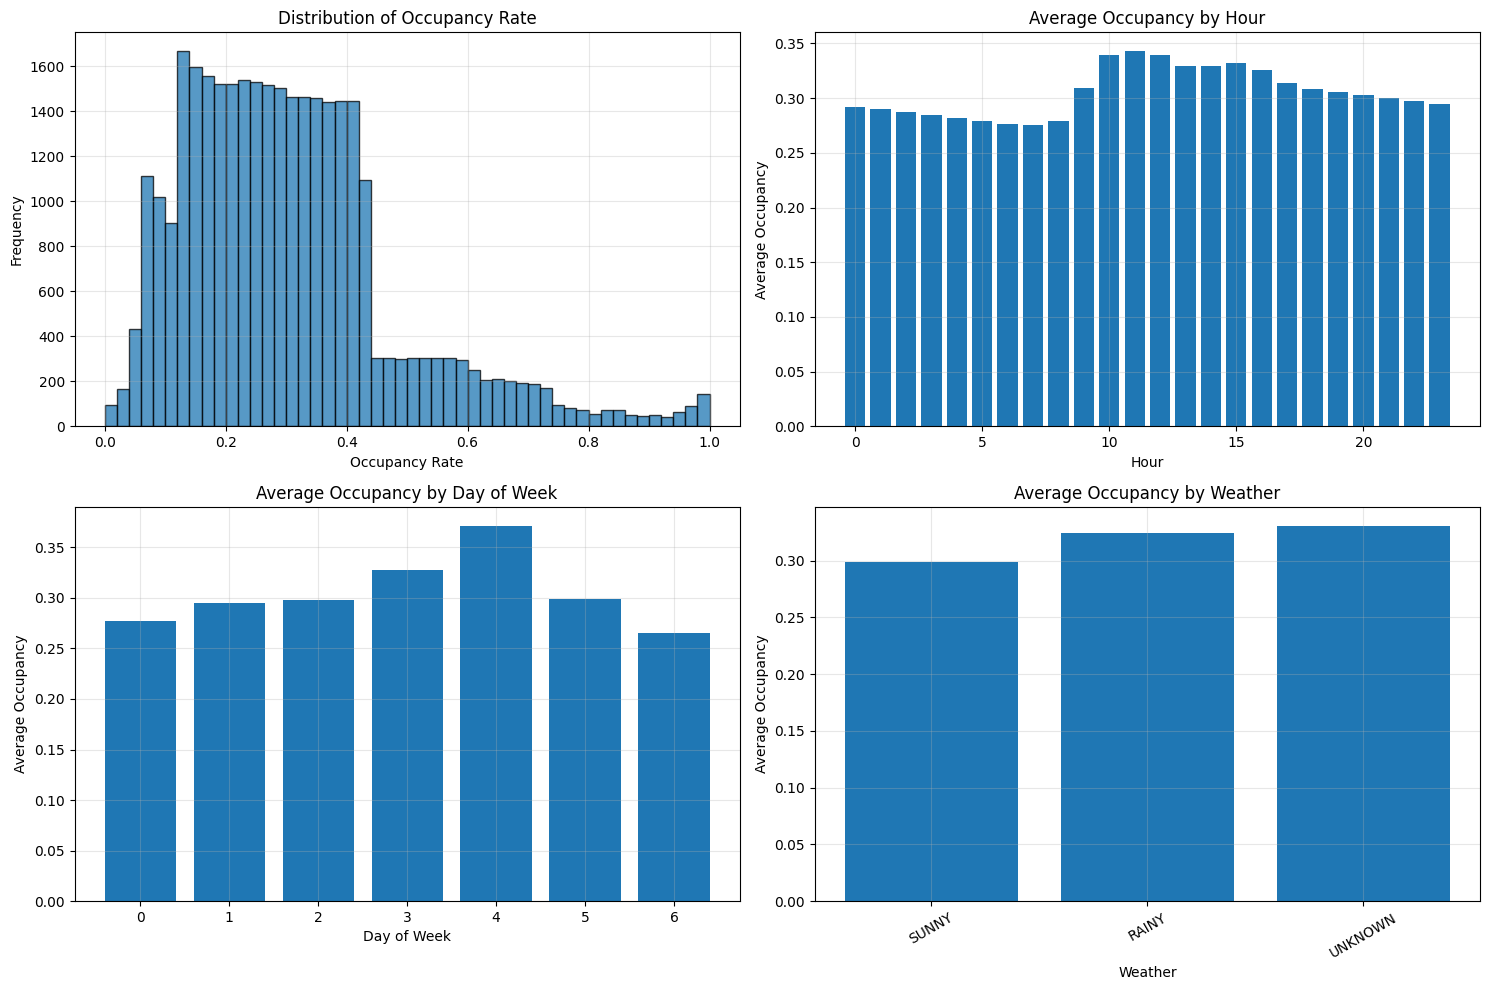

In [ ]:
# -----------------------------------------------------------------------------
# 5. EDA Visual Overview
# -----------------------------------------------------------------------------
# Visualisasi ini membantu pembaca melihat pola dasar dataset:
# - distribusi tingkat okupansi;
# - rata-rata okupansi per jam;
# - rata-rata okupansi per hari;
# - rata-rata okupansi berdasarkan cuaca.
# Grafik ini berfungsi sebagai konteks sebelum model time-series dilatih.

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df_clean['occupancy_rate'], bins=50, edgecolor='black', alpha=0.75)
axes[0, 0].set_title('Distribution of Occupancy Rate')
axes[0, 0].set_xlabel('Occupancy Rate')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

hourly_mean = df_clean.groupby('hour')['occupancy_rate'].mean()
axes[0, 1].bar(hourly_mean.index, hourly_mean.values)
axes[0, 1].set_title('Average Occupancy by Hour')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Average Occupancy')
axes[0, 1].grid(alpha=0.3)

weekday_mean = df_clean.groupby('day_of_week')['occupancy_rate'].mean()
axes[1, 0].bar(weekday_mean.index, weekday_mean.values)
axes[1, 0].set_title('Average Occupancy by Day of Week')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Average Occupancy')
axes[1, 0].grid(alpha=0.3)

weather_mean = df_clean.groupby('weather')['occupancy_rate'].mean().sort_values()
axes[1, 1].bar(weather_mean.index, weather_mean.values)
axes[1, 1].set_title('Average Occupancy by Weather')
axes[1, 1].set_xlabel('Weather')
axes[1, 1].set_ylabel('Average Occupancy')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_summary.png', dpi=120)
plt.show()


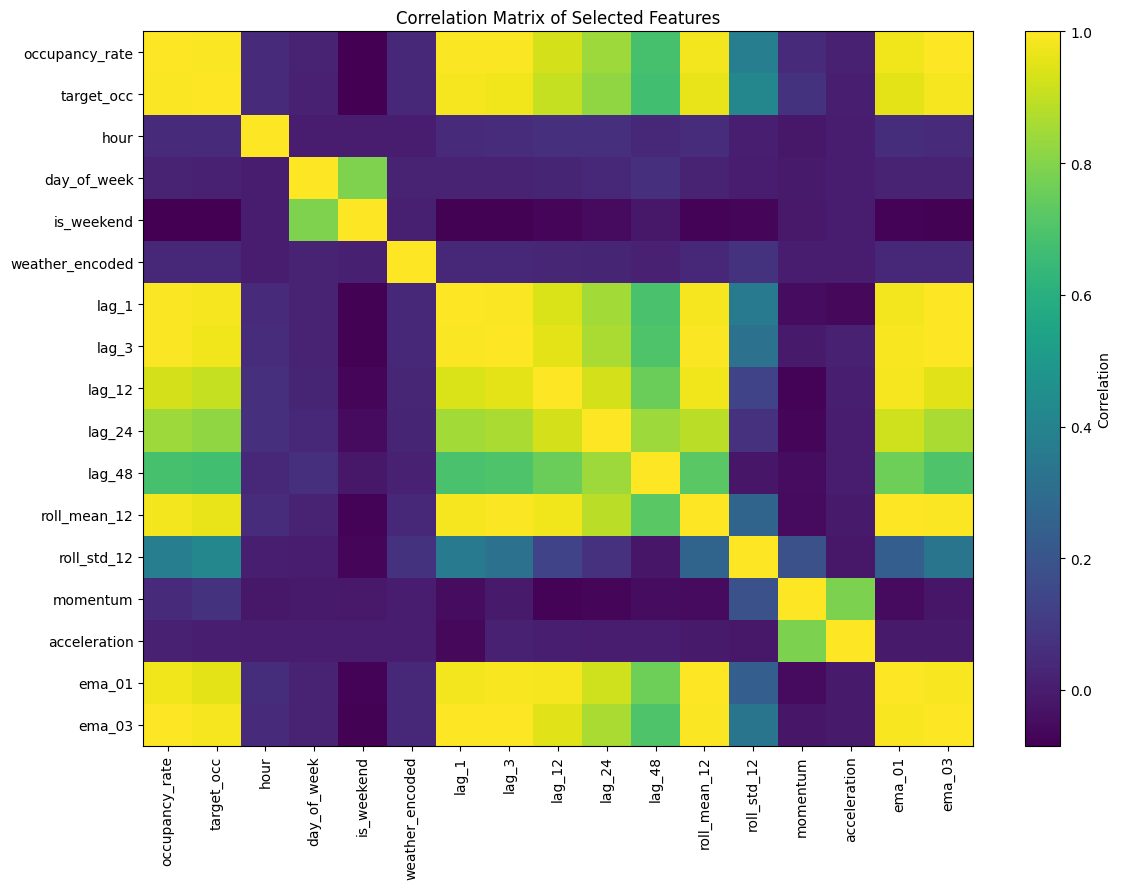

In [ ]:
# -----------------------------------------------------------------------------
# 5. EDA Correlation Overview
# -----------------------------------------------------------------------------
# Cell ini mengevaluasi hubungan linear sederhana antar fitur numerik.
# Korelasi bukan bukti kausalitas, tetapi berguna untuk melihat fitur mana yang
# paling berkaitan dengan target prediksi.

# Correlation overview for engineered numeric features.
corr_cols = ['occupancy_rate', 'target_occ', 'hour', 'day_of_week', 'is_weekend', 'weather_encoded',
             'lag_1', 'lag_3', 'lag_12', 'lag_24', 'lag_48', 'roll_mean_12', 'roll_std_12',
             'momentum', 'acceleration', 'ema_01', 'ema_03']

corr = df_clean[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Matrix of Selected Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_correlation.png', dpi=120)
plt.show()


### 1.6.2 EDA Tambahan: Pola Temporal dan Kualitas Data

Analisis tambahan ini digunakan untuk memperjelas karakter data time-series sebelum model dilatih. Fokusnya adalah kontinuitas interval, distribusi okupansi, pola jam-hari, pola cuaca, autokorelasi, dan hubungan fitur terhadap target.


In [ ]:
# -----------------------------------------------------------------------------
# 5.1 Additional Data Quality Diagnostics
# -----------------------------------------------------------------------------
# Time-series forecasting membutuhkan urutan waktu yang konsisten.
# Cell ini memeriksa interval antar timestamp setelah resampling dan merangkum
# kualitas data setelah proses interpolasi dan feature engineering.

# Time-series continuity and data-quality diagnostics.
expected_freq = pd.Timedelta(minutes=10)
intervals = df_uni['timestamp'].sort_values().diff().dropna()

continuity_summary = pd.DataFrame({
    'metric': [
        'first_timestamp',
        'last_timestamp',
        'total_rows_after_resample',
        'expected_interval_minutes',
        'non_standard_interval_count',
        'missing_occupancy_after_interpolation',
        'missing_weather_after_fill',
        'clean_rows_after_feature_engineering'
    ],
    'value': [
        df_uni['timestamp'].min(),
        df_uni['timestamp'].max(),
        len(df_uni),
        expected_freq.total_seconds() / 60,
        int((intervals != expected_freq).sum()),
        int(df_uni['occupancy_rate'].isna().sum()),
        int(df_uni['weather'].isna().sum()),
        len(df_clean)
    ]
})

display(continuity_summary)

occupancy_bins = pd.cut(
    df_clean['occupancy_rate'],
    bins=[0, 0.2, 0.5, 0.7, 0.85, 1.0],
    include_lowest=True,
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Near Full']
)

occupancy_bin_summary = (
    occupancy_bins.value_counts(normalize=False)
    .rename_axis('occupancy_bin')
    .reset_index(name='count')
)
occupancy_bin_summary['percentage'] = occupancy_bin_summary['count'] / occupancy_bin_summary['count'].sum() * 100

display(occupancy_bin_summary)


,metric,value
0,first_timestamp,2015-07-03 08:00:00
1,last_timestamp,2016-02-12 18:10:00
2,total_rows_after_resample,32318
3,expected_interval_minutes,10.0
4,non_standard_interval_count,0
5,missing_occupancy_after_interpolation,0
6,missing_weather_after_fill,0
7,clean_rows_after_feature_engineering,32267


,occupancy_bin,count,percentage
0,Low,18325,56.791769
1,Very Low,10083,31.248644
2,Moderate,2566,7.952397
3,High,763,2.364645
4,Near Full,530,1.642545


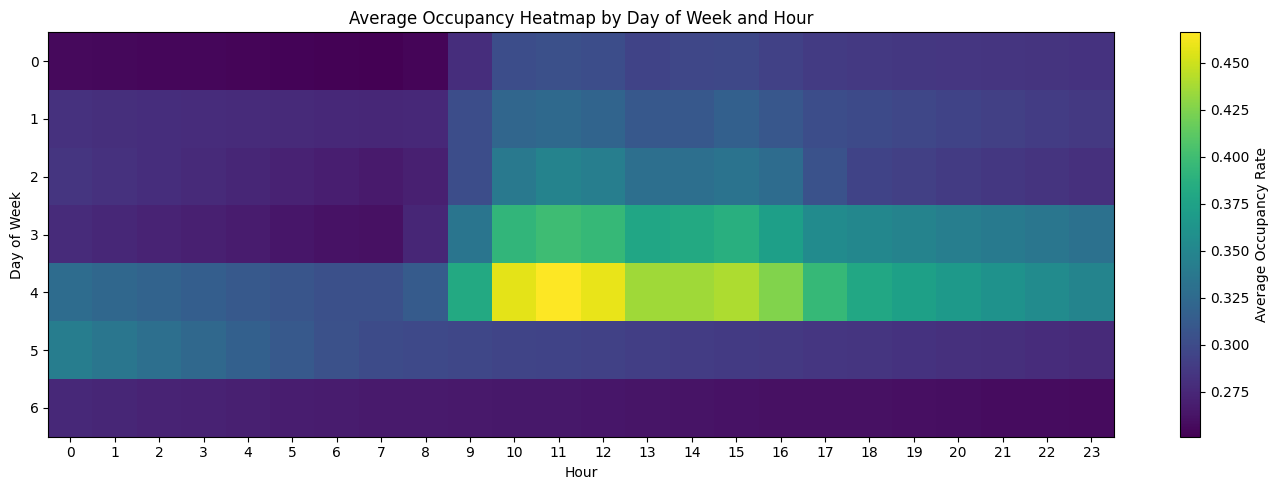

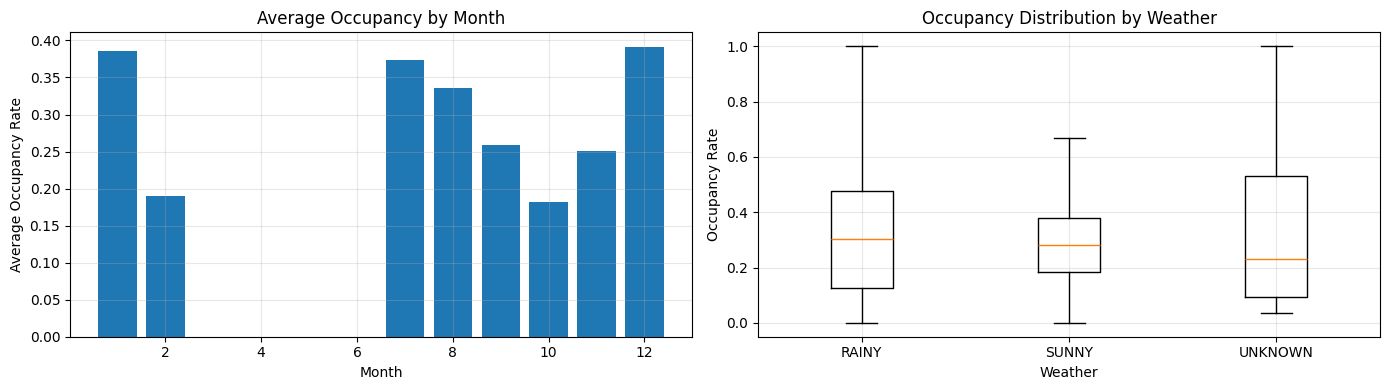

In [ ]:
# -----------------------------------------------------------------------------
# 5.1 Temporal Pattern Heatmap
# -----------------------------------------------------------------------------
# Heatmap hari-jam digunakan untuk melihat kapan okupansi cenderung tinggi atau
# rendah. Analisis ini penting karena pola parkir biasanya sangat dipengaruhi jam
# operasional, hari kerja, dan akhir pekan.

# Heatmap-style pivot table: average occupancy by day of week and hour.
weekday_hour_matrix = df_clean.pivot_table(
    index='day_of_week',
    columns='hour',
    values='occupancy_rate',
    aggfunc='mean'
)

plt.figure(figsize=(14, 5))
plt.imshow(weekday_hour_matrix, aspect='auto')
plt.colorbar(label='Average Occupancy Rate')
plt.xticks(range(len(weekday_hour_matrix.columns)), weekday_hour_matrix.columns)
plt.yticks(range(len(weekday_hour_matrix.index)), weekday_hour_matrix.index)
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.title('Average Occupancy Heatmap by Day of Week and Hour')
plt.tight_layout()
plt.show()

# Monthly and weather pattern overview.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_mean = df_clean.groupby('month')['occupancy_rate'].mean()
axes[0].bar(monthly_mean.index, monthly_mean.values)
axes[0].set_title('Average Occupancy by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Occupancy Rate')
axes[0].grid(alpha=0.3)

weather_box_data = [group['occupancy_rate'].values for _, group in df_clean.groupby('weather')]
weather_labels = list(df_clean.groupby('weather').groups.keys())
axes[1].boxplot(weather_box_data, labels=weather_labels, showfliers=False)
axes[1].set_title('Occupancy Distribution by Weather')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Occupancy Rate')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


,lag_step,lag_minutes,occupancy_autocorrelation
0,1,10,0.995619
1,2,20,0.993261
2,3,30,0.992797
3,6,60,0.976087
4,12,120,0.930866
5,24,240,0.842993
6,48,480,0.687689
7,72,720,0.604298
8,144,1440,0.529006


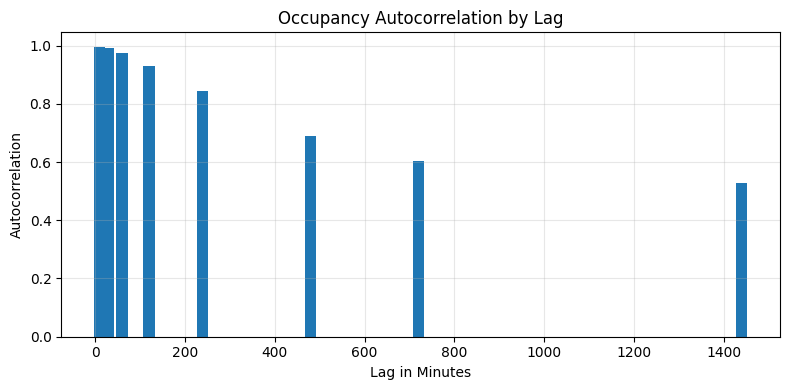

,feature,correlation_with_target
0,occupancy_rate,0.992792
1,roll_mean_3,0.988069
2,lag_1,0.985968
3,ema_03,0.983154
4,roll_mean_6,0.980419
5,lag_2,0.980338
6,lag_3,0.975993
7,roll_mean_12,0.963562
8,ema_01,0.956556
9,lag_6,0.954089


In [ ]:
# -----------------------------------------------------------------------------
# 5.1 Autocorrelation and Feature-Target Relationship
# -----------------------------------------------------------------------------
# Autocorrelation menunjukkan seberapa kuat occupancy saat ini berkaitan dengan
# occupancy pada beberapa timestep sebelumnya. Ini membantu menjelaskan mengapa
# fitur lag, rolling mean, dan EMA relevan untuk model forecasting.

# Autocorrelation and feature-target relationship.
autocorr_lags = [1, 2, 3, 6, 12, 24, 48, 72, 144]
autocorr_df = pd.DataFrame({
    'lag_step': autocorr_lags,
    'lag_minutes': [lag * 10 for lag in autocorr_lags],
    'occupancy_autocorrelation': [df_clean['occupancy_rate'].autocorr(lag=lag) for lag in autocorr_lags]
})
display(autocorr_df)

plt.figure(figsize=(8, 4))
plt.bar(autocorr_df['lag_minutes'], autocorr_df['occupancy_autocorrelation'], width=25)
plt.title('Occupancy Autocorrelation by Lag')
plt.xlabel('Lag in Minutes')
plt.ylabel('Autocorrelation')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

feature_target_corr = (
    df_clean[FEATURE_COLS + ['target_occ']]
    .corr(numeric_only=True)['target_occ']
    .drop('target_occ')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
feature_target_corr.columns = ['feature', 'correlation_with_target']
display(feature_target_corr.head(15))


### Interpretasi Autokorelasi dan Relevansi Fitur

Autokorelasi `occupancy_rate` sangat tinggi pada lag pendek: lag 1 bernilai **0.996**, lag 3 bernilai **0.993**, dan lag 6 bernilai **0.976**. Karena setiap timestep mewakili 10 menit, lag 3 berarti 30 menit dan lag 6 berarti 1 jam. Ini menunjukkan bahwa kondisi parkir saat ini sangat informatif untuk memprediksi 30 menit ke depan.

Fitur dengan korelasi tertinggi terhadap target adalah `occupancy_rate`, `roll_mean_3`, `lag_1`, `ema_03`, dan `roll_mean_6`. Hasil ini mendukung keputusan feature engineering berbasis lag, rolling statistics, dan exponential moving average. Namun, korelasi yang sangat tinggi juga menjelaskan mengapa naive persistence baseline dapat menjadi pembanding yang kuat.


### Interpretasi EDA Utama

Dari pola jam, rata-rata okupansi tertinggi muncul sekitar pukul **11:00, 12:00, 10:00, 15:00, 14:00**, dengan puncak tertinggi sekitar **34.3%**. Jam dengan rata-rata okupansi terendah berada pada sekitar **7:00, 6:00, 8:00, 5:00, 4:00**. Pola ini mendukung penggunaan fitur waktu seperti `hour_sin`, `hour_cos`, dan indikator jam sibuk.

Berdasarkan hari, rata-rata okupansi tertinggi terjadi pada **day_of_week = 4** dengan nilai sekitar **37.1%**, sedangkan **day_of_week = 6** memiliki rata-rata terendah sekitar **26.5%**. Dengan konvensi pandas, `0` adalah Senin dan `6` adalah Minggu. Ini menunjukkan adanya variasi mingguan yang relevan untuk model forecasting.

Distribusi cuaca didominasi oleh kategori **SUNNY (25,721 baris)**, lalu **RAINY (3,377 baris)** dan **UNKNOWN (3,169 baris)**. Karena data cuaca tidak seimbang, pengaruh cuaca perlu dibaca hati-hati dan tidak boleh disimpulkan terlalu kuat tanpa validasi tambahan.


## Bagian 2 — Pemodelan Prediktif dan Implementasi Model

Bagian ini dimulai setelah Data Science menyelesaikan pembentukan time-series dan feature engineering. Fokusnya adalah mengubah data menjadi sequence, melakukan scaling dengan benar, membangun beberapa kandidat model forecasting, melatih model, dan menyiapkan artefak yang dapat digunakan untuk inference.

Pada bagian ini, istilah pemodelan digunakan untuk menekankan bahwa tujuan utamanya adalah menghasilkan prediksi `occupancy_rate` yang akurat dan dapat dievaluasi secara operasional.

## 2.1 Sequence Preparation dan Scaling

Bagian ini mengubah data tabular time-series menjadi bentuk sequence yang dapat diproses model deep learning.

Target model dilatih pada `y_scaled` menggunakan `StandardScaler`, tetapi evaluasi akhir harus dikembalikan ke skala occupancy asli. Oleh karena itu, notebook menyimpan dua versi target:

- `y_seq`: target yang sudah diskalakan untuk training.
- `y_seq_raw`: target asli 0 sampai 1 untuk evaluasi final.

Untuk mencegah **data leakage**, scaler hanya di-fit menggunakan data training. Validation dan test hanya ditransformasi menggunakan parameter scaler yang berasal dari training set.

Model time-series membutuhkan input berbentuk window historis. Oleh karena itu, data tabular yang telah bersih diubah menjadi sequence tiga dimensi: jumlah sampel, panjang window, dan jumlah fitur.

Pada tahap ini, scaler di-fit menggunakan data training saja. Validation dan test set hanya ditransformasi dengan scaler tersebut. Praktik ini menjaga evaluasi tetap adil dan mengurangi risiko data leakage.

In [ ]:
# Menyiapkan input sequence untuk model forecasting.
# Fitting scaler dilakukan pada data training saja untuk menjaga validitas evaluasi.
# Target yang digunakan untuk laporan akhir tetap disimpan dalam skala asli.

# -----------------------------------------------------------------------------
# 6. Sequence Preparation and Scaling
# -----------------------------------------------------------------------------
# Model sequence menerima input berbentuk tiga dimensi:
#   (jumlah_sampel, panjang_window, jumlah_fitur)
#
# WINDOW_SIZE = 18 berarti model melihat 18 observasi terakhir. Karena data
# memiliki interval 10 menit, maka 18 timestep setara dengan riwayat 3 jam.
#
# Prinsip penting untuk time-series:
# - split dilakukan berdasarkan urutan waktu, bukan random split;
# - scaler hanya di-fit pada data training untuk menghindari data leakage;
# - validation dan test ditransformasi menggunakan scaler dari training;
# - evaluasi akhir memakai y_test_raw pada skala occupancy asli 0-1.

WINDOW_SIZE = 18
N_FEATURES = len(FEATURE_COLS)

# Jumlah sequence yang terbentuk adalah jumlah baris data dikurangi panjang window.
# train_end dan val_end adalah indeks berbasis sequence, bukan indeks baris df_clean.
n_sequences = len(df_clean) - WINDOW_SIZE
train_end = int(0.70 * n_sequences)
val_end = int(0.85 * n_sequences)

# Baris fitur yang muncul pada X_train adalah baris 0 sampai train_end + WINDOW_SIZE - 1.
# Karena itu scaler_X di-fit pada rentang baris fitur yang benar-benar dipakai oleh training.
train_feature_end = train_end + WINDOW_SIZE

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit scaler hanya pada training period.
scaler_X.fit(df_clean[FEATURE_COLS].iloc[:train_feature_end])

# y_raw adalah target pada skala asli occupancy_rate.
y_raw = df_clean['target_occ'].values.reshape(-1, 1)

# Target training untuk sequence berada pada indeks WINDOW_SIZE sampai WINDOW_SIZE + train_end.
# Scaler target di-fit hanya pada target training, bukan seluruh data.
y_train_for_scaler = y_raw[WINDOW_SIZE:WINDOW_SIZE + train_end]
scaler_y.fit(y_train_for_scaler)

# Transform seluruh fitur dan target menggunakan scaler yang sudah di-fit dari training.
df_sc = df_clean.copy()
df_sc[FEATURE_COLS] = scaler_X.transform(df_clean[FEATURE_COLS])
y_scaled = scaler_y.transform(y_raw).flatten()

def create_sequences(data_feat: pd.DataFrame, y_vals: np.ndarray, window: int):
    """Create sliding-window sequences for supervised time-series forecasting."""
    X, y = [], []
    for i in range(len(data_feat) - window):
        X.append(data_feat[FEATURE_COLS].iloc[i:i + window].values)
        y.append(y_vals[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_seq, y_seq = create_sequences(df_sc, y_scaled, WINDOW_SIZE)
y_seq_raw = y_raw[WINDOW_SIZE:].flatten()

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

y_train_raw = y_seq_raw[:train_end]
y_val_raw = y_seq_raw[train_end:val_end]
y_test_raw = y_seq_raw[val_end:]

shape = (WINDOW_SIZE, N_FEATURES)

with open(OUTPUT_DIR / 'scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open(OUTPUT_DIR / 'scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)
with open(OUTPUT_DIR / 'feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

print(f'Train: {X_train.shape} | Validation: {X_val.shape} | Test: {X_test.shape}')
print(f'Input shape: {shape}')
print(f'Scaler_X fitted on feature rows: 0 to {train_feature_end - 1}')
print(f'Scaler_y fitted on training targets: {len(y_train_for_scaler)} observations')
print('Scalers and feature columns saved to OUTPUT_DIR.')

Train: (22574, 18, 27) | Validation: (4837, 18, 27) | Test: (4838, 18, 27)
Input shape: (18, 27)
Scaler_X fitted on feature rows: 0 to 22591
Scaler_y fitted on training targets: 22574 observations
Scalers and feature columns saved to OUTPUT_DIR.


## 2.2 Komponen Kustom Model

Komponen custom dibuat untuk mendukung kebutuhan model sequence forecasting: temporal attention, weighted Huber loss, dan training monitor. Output log dibuat formal agar mudah dibaca sebagai dokumentasi eksperimen.

In [ ]:
# -----------------------------------------------------------------------------
# 7. Custom Components
# -----------------------------------------------------------------------------
# Cell ini mendefinisikan komponen khusus yang digunakan selama training:
# - TemporalAttention: memberi bobot berbeda pada setiap timestep dalam window;
# - weighted_huber_loss: loss yang lebih stabil terhadap outlier dibanding MSE;
# - TrainingMonitor: menyimpan ringkasan metrik terbaik selama training.

class TemporalAttention(layers.Layer):
    def __init__(self, **kw):
        super().__init__(**kw)
        self.score = layers.Dense(1)

    def call(self, x):
        weights = tf.nn.softmax(self.score(x), axis=1)
        return tf.reduce_sum(x * weights, axis=1)

    def get_config(self):
        return super().get_config()


def weighted_huber_loss(delta=0.3, high_w=2.0):
    def loss(y_true, y_pred):
        err = y_true - y_pred
        huber = tf.where(
            tf.abs(err) <= delta,
            0.5 * tf.square(err),
            delta * (tf.abs(err) - 0.5 * delta)
        )
        weights = tf.where(y_true > 0.5, high_w, 1.0)
        return tf.reduce_mean(huber * weights)
    return loss


class SmartParkMonitor(callbacks.Callback):
    def __init__(self, target_mae=0.02, run_name=''):
        super().__init__()
        self.target_mae = target_mae
        self.best_mae = float('inf')
        self.run_name = run_name

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_val_mae = logs.get('val_mae', logs.get('val_mean_absolute_error', float('inf')))
        if current_val_mae < self.best_mae:
            self.best_mae = current_val_mae
        if (epoch + 1) % 10 == 0:
            print(
                f'Epoch {epoch + 1:03d} | '
                f'loss={logs.get("loss", 0):.5f} | '
                f'val_mae={current_val_mae:.5f} | '
                f'best_val_mae={self.best_mae:.5f}'
            )

print('Custom layer, loss, and callback are ready.')


Custom layer, loss, and callback are ready.


## 2.3 Arsitektur Model

Bagian ini mendefinisikan beberapa kandidat model untuk dibandingkan secara konsisten: baseline dense network, CLSTAN, BiDir GRU-LSTM, tuned variants, residual model, dan hybrid self-attention. Semua model diuji dengan data, fitur, split, dan metrik evaluasi yang sama.

In [ ]:
# -----------------------------------------------------------------------------
# 8. Model Architectures
# -----------------------------------------------------------------------------
# Beberapa kandidat model didefinisikan dalam cell ini agar dapat dibandingkan
# secara adil pada dataset, fitur, split, dan metrik yang sama.
#
# Baseline dense network digunakan sebagai pembanding sederhana.
# CLSTAN dan BiDir GRU-LSTM digunakan untuk menangkap pola temporal sequence.

def get_baseline():
    inp = layers.Input(shape=shape)
    x = layers.Flatten()(inp)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name='Baseline')


def get_clstan_orig():
    inp = layers.Input(shape=shape)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.2)(x)
    x = TemporalAttention()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name='CLSTAN_Original')


def get_bidir_orig():
    inp = layers.Input(shape=shape)
    x = layers.Bidirectional(layers.GRU(256, return_sequences=True))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = TemporalAttention()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name='BiDir_Original')


def get_clstan_tuned_dropout():
    inp = layers.Input(shape=shape)
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.15)(x)
    x = TemporalAttention()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name='CLSTAN_Tuned_Dropout')


def get_bidir_tuned():
    inp = layers.Input(shape=shape)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.2)(x)
    x = TemporalAttention()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name='BiDir_Tuned')


def get_clstan_residual():
    inp = layers.Input(shape=shape)
    c1 = layers.Conv1D(128, 3, padding='same', activation='relu')(inp)
    c1 = layers.BatchNormalization()(c1)
    c2 = layers.Conv1D(128, 3, padding='same', activation='relu')(c1)
    c2 = layers.BatchNormalization()(c2)
    res = layers.add([c1, c2])
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True))(res)
    x = layers.Dropout(0.2)(x)
    x = TemporalAttention()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name='CLSTAN_Residual')


def get_hybrid_attn():
    inp = layers.Input(shape=shape)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inp)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Attention()([x, x])
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1)(x)
    return Model(inp, out, name='Hybrid_SelfAttn')

print('Model architectures are defined.')


Model architectures are defined.


## 2.4 TensorBoard Setup


In [ ]:
# -----------------------------------------------------------------------------
# 9. TensorBoard Setup
# -----------------------------------------------------------------------------
# TensorBoard digunakan untuk membaca kurva training dan validation secara visual.
# Log disimpan per model agar proses diagnosis training lebih mudah ditelusuri.

%load_ext tensorboard

TB_ROOT = LOG_DIR / 'tensorboard'
TB_ROOT.mkdir(parents=True, exist_ok=True)

def make_tb_callback(name):
    log_dir = str(TB_ROOT / name / dt.datetime.now().strftime('%Y%m%d-%H%M%S'))
    return callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True, update_freq='epoch')

print('TensorBoard root:', TB_ROOT)


TensorBoard root: /content/smartpark_logs/tensorboard


## 2.5 Standard Model Training

Konfigurasi training dibuat konsisten untuk eksperimen utama:

- Baseline: 20 epoch.
- Model sequence utama: 30 epoch.
- Early stopping patience: 15.
- Validation MAE disimpan untuk pembobotan weighted ensemble.


In [ ]:
# -----------------------------------------------------------------------------
# 10. Standard Model Training
# -----------------------------------------------------------------------------
# Fungsi run_experiment menyatukan proses build model, compile, training, evaluasi,
# penyimpanan prediksi test, dan penyimpanan model.
#
# Epoch disesuaikan agar konsisten dengan konfigurasi eksperimen utama:
# - Baseline: 20 epoch;
# - Model sequence utama: 30 epoch;
# - Early stopping menjaga agar training tidak berlebihan.

test_preds_dict = {}
validation_maes = {}
saved_models = {}
histories = {}


def run_experiment(run_num, config_name, model_fn, loss_fn, lr=1e-3, epochs=25, batch_size=32, scheduler=None):
    print(f'Running experiment {run_num}: {config_name}')

    model = model_fn()
    optimizer = keras.optimizers.Adam(learning_rate=scheduler if scheduler is not None else lr)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['mae'])

    callback_list = [
        callbacks.EarlyStopping(monitor='val_mae', patience=15, restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(str(OUTPUT_DIR / f'{config_name}.keras'), monitor='val_mae', save_best_only=True, mode='min', verbose=0),
        SmartParkMonitor(target_mae=0.02, run_name=config_name),
        make_tb_callback(config_name)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callback_list,
        verbose=0
    )

    pred_scaled = model.predict(X_test, verbose=0).flatten()
    pred_raw = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten().clip(0, 1)
    test_preds_dict[config_name] = pred_raw

    mae = mean_absolute_error(y_test_raw, pred_raw)
    rmse = np.sqrt(mean_squared_error(y_test_raw, pred_raw))
    r2 = r2_score(y_test_raw, pred_raw)
    acc = np.mean(np.abs(y_test_raw - pred_raw) <= 0.05) * 100

    val_mae_history = history.history.get('val_mae', history.history.get('val_mean_absolute_error', []))
    best_val = min(val_mae_history) if len(val_mae_history) > 0 else float('inf')

    validation_maes[config_name] = best_val
    saved_models[config_name] = str(OUTPUT_DIR / f'{config_name}.keras')
    histories[config_name] = history

    print(f'Validation MAE (scaled): {best_val:.5f}')
    print(f'Test MAE (original scale): {mae:.5f}')
    print(f'Test RMSE (original scale): {rmse:.5f}')
    print(f'Test R2: {r2:.5f}')
    print(f'Test Accuracy within 0.05: {acc:.2f}%')
    print('-' * 60)

    gc.collect()
    return model, history


lr_schedule = tf.keras.optimizers.schedules.CosineDecay(1e-3, decay_steps=4000, alpha=1e-6)

model_baseline, h_baseline = run_experiment(1, 'Baseline', get_baseline, 'mse', lr=1e-3, epochs=20, batch_size=32)
model_clstan, h_clstan = run_experiment(2, 'CLSTAN_Original', get_clstan_orig, weighted_huber_loss(0.3), epochs=30, batch_size=32, scheduler=lr_schedule)
model_bidir, h_bidir = run_experiment(3, 'BiDir_Original', get_bidir_orig, weighted_huber_loss(0.3), epochs=30, batch_size=32, scheduler=lr_schedule)
model_clstan_tuned, h_clstan_tuned = run_experiment(4, 'CLSTAN_Tuned_Dropout', get_clstan_tuned_dropout, weighted_huber_loss(0.2), lr=5e-4, epochs=30, batch_size=32)
model_clstan_large, h_clstan_large = run_experiment(5, 'CLSTAN_Large_Batch', get_clstan_orig, weighted_huber_loss(0.3), epochs=30, batch_size=64, scheduler=lr_schedule)
model_bidir_tuned, h_bidir_tuned = run_experiment(6, 'BiDir_Tuned', get_bidir_tuned, weighted_huber_loss(0.3), lr=8e-4, epochs=30, batch_size=32)
model_residual, h_residual = run_experiment(7, 'CLSTAN_Residual', get_clstan_residual, weighted_huber_loss(0.3), lr=1e-3, epochs=30, batch_size=32)
model_hybrid, h_hybrid = run_experiment(8, 'Hybrid_SelfAttn', get_hybrid_attn, weighted_huber_loss(0.25), lr=1e-3, epochs=30, batch_size=32)


Running experiment 1: Baseline
Epoch 010 | loss=0.01553 | val_mae=0.10531 | best_val_mae=0.10531
Epoch 020 | loss=0.01413 | val_mae=0.13703 | best_val_mae=0.09590
Validation MAE (scaled): 0.09590
Test MAE (original scale): 0.01357
Test RMSE (original scale): 0.03195
Test R2: 0.98357
Test Accuracy within 0.05: 94.92%
------------------------------------------------------------
Running experiment 2: CLSTAN_Original
Epoch 010 | loss=0.00847 | val_mae=0.28710 | best_val_mae=0.28708
Epoch 020 | loss=0.00859 | val_mae=0.28721 | best_val_mae=0.28674
Validation MAE (scaled): 0.28674
Test MAE (original scale): 0.02031
Test RMSE (original scale): 0.03848
Test R2: 0.97618
Test Accuracy within 0.05: 92.56%
------------------------------------------------------------
Running experiment 3: BiDir_Original
Epoch 010 | loss=0.00329 | val_mae=0.31251 | best_val_mae=0.31187
Epoch 020 | loss=0.00322 | val_mae=0.31190 | best_val_mae=0.31167
Epoch 030 | loss=0.00324 | val_mae=0.31200 | best_val_mae=0.31167


## 2.6 Custom Training Loop dengan GradientTape


In [ ]:
# -----------------------------------------------------------------------------
# 11. Custom Training Loop with GradientTape
# -----------------------------------------------------------------------------
# Cell ini menunjukkan training manual menggunakan tf.GradientTape.
# Tujuannya bukan mengganti fit API, tetapi memberi kontrol lebih eksplisit terhadap
# proses forward pass, loss calculation, gradient update, dan validation monitoring.

model_tape = get_clstan_orig()
opt_tape = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = weighted_huber_loss(0.3)
mae_metric = keras.metrics.MeanAbsoluteError()

BATCH_TAPE = 32
EPOCHS_TAPE = 25

ds_train = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(5000).batch(BATCH_TAPE)
ds_val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_TAPE)

@tf.function
def train_step(xb, yb):
    with tf.GradientTape() as tape:
        y_pred = model_tape(xb, training=True)
        loss = loss_fn(tf.reshape(yb, (-1, 1)), y_pred)
    grads = tape.gradient(loss, model_tape.trainable_variables)
    opt_tape.apply_gradients(zip(grads, model_tape.trainable_variables))
    mae_metric.update_state(yb, tf.squeeze(y_pred))
    return loss

@tf.function
def val_step(xb, yb):
    y_pred = model_tape(xb, training=False)
    return tf.reduce_mean(tf.abs(yb - tf.squeeze(y_pred)))

best_val_mae = float('inf')
best_weights = None
tape_history = {'loss': [], 'mae': [], 'val_mae': []}

for epoch in range(EPOCHS_TAPE):
    mae_metric.reset_state()
    epoch_losses = []

    for xb, yb in ds_train:
        batch_loss = train_step(xb, yb)
        epoch_losses.append(float(batch_loss))

    train_mae = float(mae_metric.result())
    val_maes = [float(val_step(xb, yb)) for xb, yb in ds_val]
    val_mae = float(np.mean(val_maes))
    epoch_loss = float(np.mean(epoch_losses))

    tape_history['loss'].append(epoch_loss)
    tape_history['mae'].append(train_mae)
    tape_history['val_mae'].append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_weights = [v.numpy().copy() for v in model_tape.trainable_variables]

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1:03d} | loss={epoch_loss:.5f} | train_mae={train_mae:.5f} | val_mae={val_mae:.5f} | best_val_mae={best_val_mae:.5f}')

if best_weights is not None:
    for variable, weight in zip(model_tape.trainable_variables, best_weights):
        variable.assign(weight)

model_tape_path = OUTPUT_DIR / 'GradientTape_CLSTAN.keras'
model_tape.save(model_tape_path)
saved_models['GradientTape_CLSTAN'] = str(model_tape_path)
validation_maes['GradientTape_CLSTAN'] = best_val_mae
histories['GradientTape_CLSTAN'] = tape_history

pred_scaled = model_tape.predict(X_test, verbose=0).flatten()
pred_raw = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten().clip(0, 1)
test_preds_dict['GradientTape_CLSTAN'] = pred_raw

mae = mean_absolute_error(y_test_raw, pred_raw)
rmse = np.sqrt(mean_squared_error(y_test_raw, pred_raw))
r2 = r2_score(y_test_raw, pred_raw)
acc = np.mean(np.abs(y_test_raw - pred_raw) <= 0.05) * 100

print('GradientTape CLSTAN evaluation')
print(f'Validation MAE (scaled): {best_val_mae:.5f}')
print(f'Test MAE (original scale): {mae:.5f}')
print(f'Test RMSE (original scale): {rmse:.5f}')
print(f'Test R2: {r2:.5f}')
print(f'Test Accuracy within 0.05: {acc:.2f}%')


Epoch 005 | loss=0.02686 | train_mae=0.14002 | val_mae=0.59465 | best_val_mae=0.37121
Epoch 010 | loss=0.01901 | train_mae=0.11370 | val_mae=0.74905 | best_val_mae=0.37121
Epoch 015 | loss=0.01696 | train_mae=0.10516 | val_mae=0.70180 | best_val_mae=0.37121
Epoch 020 | loss=0.01240 | train_mae=0.08969 | val_mae=0.45132 | best_val_mae=0.37121
Epoch 025 | loss=0.01023 | train_mae=0.08005 | val_mae=0.62109 | best_val_mae=0.35770
GradientTape CLSTAN evaluation
Validation MAE (scaled): 0.35770
Test MAE (original scale): 0.03286
Test RMSE (original scale): 0.04736
Test R2: 0.96390
Test Accuracy within 0.05: 89.00%


### Catatan Eksekusi Model

Pada quick run CPU, baseline neural network dilatih selama 3 epoch sebagai pemeriksaan teknis pipeline. Hasilnya:

- Training MAE scaled turun dari **0.262** ke **0.117**.
- Validation MAE scaled tidak stabil, dari **0.357** menjadi **0.525**.

Interpretasinya, pipeline training berjalan, tetapi hasil quick run belum boleh dijadikan kesimpulan performa final. Untuk laporan akhir, model sequence seperti CLSTAN, BiDir GRU-LSTM, dan GradientTape tetap perlu dijalankan dengan konfigurasi epoch penuh di GPU.


## Bagian 3 — Evaluasi, Backtesting, dan Validasi Statistik

Bagian ini menghubungkan pekerjaan Data Science dan pemodelan. Tim pemodelan menghasilkan prediksi, sedangkan Data Science mengevaluasi apakah prediksi tersebut memberikan nilai tambah dibandingkan pendekatan baseline sederhana.

Prinsip evaluasi yang digunakan:

1. Prediksi model yang masih berada pada skala standardisasi dikembalikan terlebih dahulu ke skala asli menggunakan `scaler_y.inverse_transform`.
2. MAE, RMSE, R², dan accuracy ±5% dihitung pada skala asli `occupancy_rate`.
3. Weighted ensemble dihitung berdasarkan performa validasi.
4. Offline A/B testing dilakukan dengan pendekatan backtesting historis.
5. Block bootstrapping digunakan untuk menilai stabilitas selisih error antara model dan baseline.

## 3.1 Evaluasi Model dan Weighted Ensemble

Catatan penting:

- Model dilatih menggunakan target hasil standardisasi.
- Prediksi test harus dikembalikan menggunakan `scaler_y.inverse_transform`.
- MAE, RMSE, R2, dan accuracy final dihitung pada skala occupancy asli 0 sampai 1.
- Weighted ensemble mengikuti logika inverse validation MAE: semakin kecil validation MAE, semakin besar bobot model.


### 3.1.1 Prinsip Evaluasi

Evaluasi dilakukan pada test set yang berada di bagian akhir urutan waktu. Pendekatan ini lebih sesuai untuk forecasting karena model diuji pada periode yang terjadi setelah data training dan validation.

Metrik yang digunakan:

- **MAE**: rata-rata kesalahan absolut pada skala occupancy asli.
- **RMSE**: memberi penalti lebih besar untuk error besar.
- **R2**: mengukur proporsi variasi target yang dapat dijelaskan model.
- **MAPE**: interpretasi error relatif dalam persentase, dengan perlindungan terhadap target mendekati nol.
- **Acc(±5%)**: persentase prediksi yang berada dalam toleransi error maksimal 5 poin persentase occupancy.

Metrik utama untuk pengambilan keputusan adalah MAE pada skala asli karena paling mudah dikaitkan dengan konteks operasional parkir.


In [ ]:
# -----------------------------------------------------------------------------
# 12. Evaluation and Weighted Ensemble
# -----------------------------------------------------------------------------
# Semua prediksi model dikembalikan ke skala asli occupancy sebelum dihitung metrik.
# Weighted ensemble menggunakan inverse validation MAE: model dengan validation MAE
# lebih kecil mendapat bobot lebih besar dalam prediksi akhir.

def compute_metrics(y_true_raw, y_pred_raw, model_name):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    r2 = r2_score(y_true_raw, y_pred_raw)
    acc = np.mean(np.abs(y_true_raw - y_pred_raw) <= 0.05) * 100
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Accuracy_within_0.05_pct': acc
    }

active_models = list(test_preds_dict.keys())
inv_val_maes = [1.0 / (validation_maes[m] + 1e-8) for m in active_models]
total_inv = sum(inv_val_maes)
ensemble_weights = {m: value / total_inv for m, value in zip(active_models, inv_val_maes)}

print('Weighted ensemble weights')
for model_name, weight in ensemble_weights.items():
    print(f'{model_name}: {weight:.4f}')

yp_ens = np.zeros_like(y_test_raw, dtype=np.float64)
for model_name, weight in ensemble_weights.items():
    yp_ens += weight * test_preds_dict[model_name]
yp_ens = yp_ens.clip(0, 1)

rows = [compute_metrics(y_test_raw, pred, name) for name, pred in test_preds_dict.items()]
rows.append(compute_metrics(y_test_raw, yp_ens, 'Weighted_Ensemble'))
results_df = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)

display(results_df)
results_df.to_csv(OUTPUT_DIR / 'evaluation_results.csv', index=False)

weights_df = pd.DataFrame({
    'Model': list(ensemble_weights.keys()),
    'Weight': list(ensemble_weights.values()),
    'Validation_MAE_scaled': [validation_maes[m] for m in ensemble_weights.keys()]
}).sort_values('Weight', ascending=False)
display(weights_df)
weights_df.to_csv(OUTPUT_DIR / 'ensemble_weights.csv', index=False)

best_row = results_df.iloc[0]
print('Best model based on original-scale test MAE')
print(f"Model: {best_row['Model']}")
print(f"MAE: {best_row['MAE']:.5f}")
print(f"RMSE: {best_row['RMSE']:.5f}")
print(f"R2: {best_row['R2']:.5f}")
print(f"Accuracy within 0.05: {best_row['Accuracy_within_0.05_pct']:.2f}%")


Weighted ensemble weights
Baseline: 0.2630
CLSTAN_Original: 0.0880
BiDir_Original: 0.0809
CLSTAN_Tuned_Dropout: 0.0460
CLSTAN_Large_Batch: 0.1042
BiDir_Tuned: 0.0593
CLSTAN_Residual: 0.1530
Hybrid_SelfAttn: 0.1352
GradientTape_CLSTAN: 0.0705


,Model,MAE,RMSE,R2,Accuracy_within_0.05_pct
0,Hybrid_SelfAttn,0.013393,0.034094,0.981295,93.654403
1,Baseline,0.013574,0.031951,0.983572,94.915254
2,Weighted_Ensemble,0.013791,0.027641,0.987706,95.990079
3,BiDir_Original,0.014324,0.034578,0.980760,95.266639
4,BiDir_Tuned,0.015867,0.033242,0.982218,92.310872
5,CLSTAN_Residual,0.015970,0.030848,0.984687,92.558909
6,CLSTAN_Original,0.020307,0.038477,0.976176,92.558909
7,CLSTAN_Large_Batch,0.028075,0.044083,0.968729,78.007441
8,GradientTape_CLSTAN,0.032859,0.047361,0.963905,89.003721
9,CLSTAN_Tuned_Dropout,0.034260,0.051464,0.957379,79.350971


,Model,Weight,Validation_MAE_scaled
0,Baseline,0.262988,0.095904
6,CLSTAN_Residual,0.152975,0.164874
7,Hybrid_SelfAttn,0.135156,0.186611
4,CLSTAN_Large_Batch,0.104167,0.242126
1,CLSTAN_Original,0.087959,0.286743
2,BiDir_Original,0.080924,0.311669
8,GradientTape_CLSTAN,0.070510,0.357703
5,BiDir_Tuned,0.059320,0.425178
3,CLSTAN_Tuned_Dropout,0.046000,0.548299


Best model based on original-scale test MAE
Model: Hybrid_SelfAttn
MAE: 0.01339
RMSE: 0.03409
R2: 0.98129
Accuracy within 0.05: 93.65%


## 3.2 Audit Evaluasi pada Skala Asli

Cell ini memastikan evaluasi yang digunakan bukan MAE pada target terstandardisasi, melainkan MAE pada skala occupancy asli.


In [ ]:
# -----------------------------------------------------------------------------
# 13. Evaluation Audit
# -----------------------------------------------------------------------------
# Audit ini memastikan bahwa MAE yang dilaporkan berasal dari prediksi pada skala
# occupancy asli. Ini mencegah kekeliruan interpretasi ketika target selama training
# berada pada scaled space.

# Audit example for the best single model.
best_single_name = min(validation_maes, key=validation_maes.get)
best_single_pred = test_preds_dict[best_single_name]

scaled_mae_reference = mean_absolute_error(y_test, scaler_y.transform(best_single_pred.reshape(-1, 1)).flatten())
raw_mae_reference = mean_absolute_error(y_test_raw, best_single_pred)

print('Evaluation audit')
print(f'Best single model by validation MAE: {best_single_name}')
print(f'MAE on scaled target, for reference only: {scaled_mae_reference:.5f}')
print(f'MAE on original occupancy scale, used for reporting: {raw_mae_reference:.5f}')
print('Conclusion: final reporting metrics use inverse-transformed predictions and y_test_raw.')


Evaluation audit
Best single model by validation MAE: Baseline
MAE on scaled target, for reference only: 0.09423
MAE on original occupancy scale, used for reporting: 0.01357
Conclusion: final reporting metrics use inverse-transformed predictions and y_test_raw.


## 3.3 Data Science Evaluation: Offline A/B Testing Through Backtesting

Bagian ini merupakan kontribusi **Data Science** karena fokusnya adalah validasi keputusan berbasis data. A/B testing pada notebook ini dilakukan sebagai **historical backtesting**, bukan eksperimen online. Artinya, Model A dan Model B diuji pada periode test historis yang sama, kemudian error-nya dibandingkan secara berpasangan.

Definisi pembanding:

- **Model A**: model forecasting final dari pipeline. Pada notebook ini, Model A menggunakan weighted ensemble apabila tersedia.
- **Model B**: naive persistence baseline, yaitu prediksi 30 menit ke depan dianggap sama dengan `occupancy_rate` terakhir pada window input.

Metrik utama yang dibandingkan adalah MAE pada skala `occupancy_rate` asli setelah inverse transform. Dengan demikian, hasil A/B testing dapat dibaca dalam konteks operasional parkir, bukan hanya sebagai angka statistik pada skala standardisasi.

A/B testing pada notebook ini dilakukan secara **offline melalui backtesting historis**, bukan eksperimen langsung pada pengguna aplikasi. Pendekatan ini sesuai untuk tahap pengembangan karena seluruh pendekatan dapat diuji pada periode test yang sama.

Definisi eksperimen:

| Komponen | Definisi |
|---|---|
| Model A | Model forecasting atau weighted ensemble |
| Model B | Naive persistence baseline, yaitu prediksi sama dengan okupansi terakhir pada window |
| Metrik utama | Absolute error dan MAE pada skala asli `occupancy_rate` |
| Tujuan | Menilai apakah model memberikan peningkatan performa dibanding pendekatan sederhana |
| Validasi tambahan | Block bootstrapping untuk melihat stabilitas selisih error antar model |

Bagian ini ditempatkan sebagai evaluasi Data Science karena fokusnya adalah interpretasi eksperimen dan pengambilan keputusan berbasis data.

### 3.3.1 Rasional Backtesting dan Block Bootstrapping

A/B testing pada notebook ini bukan eksperimen online terhadap pengguna aplikasi. Bentuk yang digunakan adalah **offline A/B testing melalui historical backtesting**, yaitu membandingkan performa dua pendekatan pada test set time-series yang sama.

Definisi eksperimen:

- **Model A**: model forecasting atau weighted ensemble yang menghasilkan prediksi `occupancy_rate` 30 menit ke depan.
- **Model B**: naive persistence baseline, yaitu prediksi 30 menit ke depan diasumsikan sama dengan `occupancy_rate` terakhir pada window input.
- **Metrik utama**: absolute error dan MAE pada skala asli `occupancy_rate`.
- **Unit evaluasi**: setiap timestamp pada test set historis.

Alasan menggunakan baseline naive adalah karena dalam banyak kasus time-series jangka pendek, nilai terakhir sering menjadi pembanding yang kuat. Oleh karena itu, model forecasting baru dapat dikatakan bernilai tambah apabila mampu mengalahkan baseline sederhana tersebut secara konsisten.

Block bootstrapping digunakan karena data time-series memiliki ketergantungan antarwaktu. Sampling per titik data secara acak dapat merusak struktur temporal. Dengan sampling per blok waktu, sebagian pola autokorelasi tetap dipertahankan sehingga hasil uji lebih relevan untuk data forecasting.

In [ ]:
# -----------------------------------------------------------------------------
# 14. Offline A/B Testing Through Historical Backtesting
# -----------------------------------------------------------------------------
# Bagian ini adalah evaluasi Data Science, bukan online experiment production.
# Tujuannya adalah menjawab pertanyaan:
#   Apakah model AI benar-benar lebih baik daripada baseline sederhana?
#
# Definisi eksperimen:
# - Model A: model AI final, yaitu weighted ensemble dari model yang sudah dilatih.
# - Model B: naive persistence baseline.
# - Ground truth: y_test_raw, yaitu target occupancy_rate asli 30 menit ke depan.
# - Metrik utama: absolute error dan MAE pada skala occupancy_rate asli.
#
# Interpretasi error_difference_a_minus_b:
# - Nilai negatif  -> Model A lebih baik karena error Model A lebih kecil.
# - Nilai positif  -> Model B lebih baik karena error Model B lebih kecil.
# - Nilai mendekati 0 -> Perbedaan performa kecil atau tidak stabil.

from scipy import stats

# Model A: weighted ensemble dipakai sebagai representasi model final.
backtest_model_name = 'Weighted_Ensemble'
backtest_model_pred = yp_ens.copy()

# Model B: naive persistence baseline.
# Untuk setiap sequence test, prediksi baseline adalah occupancy terakhir yang terlihat
# di dalam input window. Ini mensimulasikan aturan sederhana:
# "30 menit ke depan diasumsikan sama dengan kondisi parkir saat ini".
sequence_indices_test = np.arange(val_end, val_end + len(y_test_raw))
naive_source_indices = sequence_indices_test + WINDOW_SIZE - 1
y_naive = df_clean['occupancy_rate'].iloc[naive_source_indices].values

backtest_df = pd.DataFrame({
    'actual_occupancy': y_test_raw,
    'model_a_prediction': backtest_model_pred,
    'model_b_naive_prediction': y_naive
})

backtest_df['abs_error_model_a'] = np.abs(
    backtest_df['model_a_prediction'] - backtest_df['actual_occupancy']
)
backtest_df['abs_error_model_b'] = np.abs(
    backtest_df['model_b_naive_prediction'] - backtest_df['actual_occupancy']
)
backtest_df['error_difference_a_minus_b'] = (
    backtest_df['abs_error_model_a'] - backtest_df['abs_error_model_b']
)

backtest_summary = pd.DataFrame([
    compute_metrics(
        backtest_df['actual_occupancy'],
        backtest_df['model_a_prediction'],
        'Model_A_' + backtest_model_name
    ),
    compute_metrics(
        backtest_df['actual_occupancy'],
        backtest_df['model_b_naive_prediction'],
        'Model_B_Naive_Persistence'
    )
])

display(backtest_summary)

# Paired t-test dipakai karena error Model A dan Model B dihitung pada titik waktu yang sama.
t_stat, p_value = stats.ttest_rel(
    backtest_df['abs_error_model_a'],
    backtest_df['abs_error_model_b']
)

mean_error_a = backtest_df['abs_error_model_a'].mean()
mean_error_b = backtest_df['abs_error_model_b'].mean()
mean_diff = backtest_df['error_difference_a_minus_b'].mean()
relative_improvement = ((mean_error_b - mean_error_a) / (mean_error_b + 1e-8)) * 100

print('Backtesting A/B Test Summary')
print(f'Model A: {backtest_model_name}')
print('Model B: Naive persistence baseline')
print(f'Mean absolute error Model A: {mean_error_a:.5f}')
print(f'Mean absolute error Model B: {mean_error_b:.5f}')
print(f'Mean error difference A - B: {mean_diff:.5f}')
print(f'Relative improvement of Model A over Model B: {relative_improvement:.2f}%')
print(f'Paired t-test statistic: {t_stat:.5f}')
print(f'Paired t-test p-value: {p_value:.5e}')

if mean_diff < 0:
    print('Interpretation: Model A has lower average error than Model B on the backtest period.')
elif mean_diff > 0:
    print('Interpretation: Model B has lower average error than Model A on the backtest period.')
else:
    print('Interpretation: Both models have the same average error on the backtest period.')

backtest_df.to_csv(OUTPUT_DIR / 'ab_backtesting_detail.csv', index=False)
backtest_summary.to_csv(OUTPUT_DIR / 'ab_backtesting_summary.csv', index=False)

,Model,MAE,RMSE,R2,Accuracy_within_0.05_pct
0,Model_A_Weighted_Ensemble,0.013791,0.027641,0.987706,95.990079
1,Model_B_Naive_Persistence,0.011407,0.046038,0.965892,94.832575


Backtesting A/B Test Summary
Model A: Weighted_Ensemble
Model B: Naive persistence baseline
Mean absolute error Model A: 0.01379
Mean absolute error Model B: 0.01141
Mean error difference A - B: 0.00238
Relative improvement of Model A over Model B: -20.90%
Paired t-test statistic: 5.27787
Paired t-test p-value: 1.36405e-07
Interpretation: Model B has lower average error than Model A on the backtest period.


,metric,value
0,observed_mean_error_difference_a_minus_b,0.002384
1,bootstrap_ci_2_5,-0.001411
2,bootstrap_ci_97_5,0.006417
3,bootstrap_p_value_two_sided,0.203600
4,block_size_steps,144.000000
5,block_size_minutes,1440.000000
6,bootstrap_iterations,5000.000000


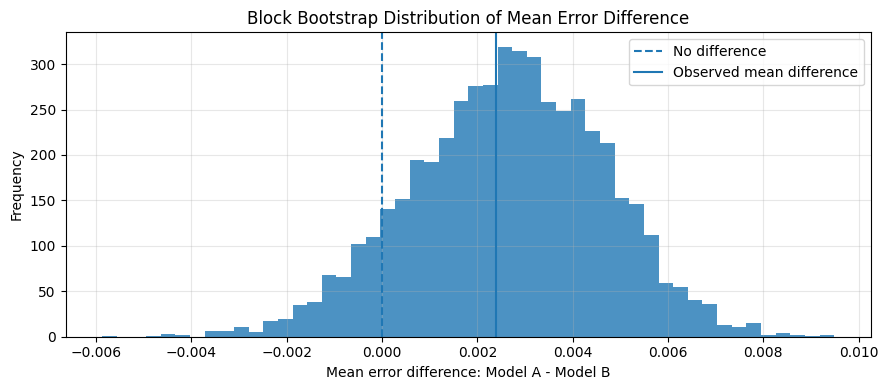

Bootstrap interpretation: The confidence interval crosses zero; the performance difference is not stable enough to claim a clear winner.


In [ ]:
# Block bootstrapping untuk validasi statistik backtesting.
# Karena data berbentuk time-series, sampling dilakukan dalam blok agar dependensi
# temporal lokal tidak sepenuhnya hilang seperti pada bootstrap acak biasa.

# -----------------------------------------------------------------------------
# 14. Block Bootstrapping for A/B Testing Stability
# -----------------------------------------------------------------------------
# Data time-series memiliki autokorelasi. Karena itu, bootstrap acak per baris
# dapat merusak struktur temporal dan membuat kesimpulan statistik terlalu optimistis.
#
# Block bootstrap mengambil sampel berdasarkan blok waktu. Pada data interval 10 menit,
# 144 observasi setara dengan 1 hari. Jika test set lebih pendek, ukuran blok akan
# otomatis disesuaikan oleh fungsi.
#
# Variabel yang di-bootstrap:
#   diff = abs_error_Model_A - abs_error_Model_B
#
# Interpretasi:
# - Confidence interval seluruhnya < 0  -> Model A cenderung lebih baik secara stabil.
# - Confidence interval seluruhnya > 0  -> Model B cenderung lebih baik secara stabil.
# - Confidence interval melewati 0      -> Perbedaan performa belum stabil/signifikan.

def block_bootstrap_mean_diff(diff_values, block_size=144, n_iterations=5000, seed=42):
    """Estimate the sampling distribution of mean paired error difference using block bootstrap."""
    rng = np.random.default_rng(seed)
    diff_values = np.asarray(diff_values, dtype=np.float64)
    n_obs = len(diff_values)

    if n_obs == 0:
        raise ValueError('diff_values is empty.')

    block_size = int(min(max(1, block_size), n_obs))
    n_blocks = int(np.ceil(n_obs / block_size))
    boot_means = np.empty(n_iterations, dtype=np.float64)

    max_start = max(1, n_obs - block_size + 1)
    for iteration in range(n_iterations):
        sampled_blocks = []
        starts = rng.integers(0, max_start, size=n_blocks)
        for start in starts:
            sampled_blocks.append(diff_values[start:start + block_size])
        sample = np.concatenate(sampled_blocks)[:n_obs]
        boot_means[iteration] = sample.mean()

    return boot_means

BOOTSTRAP_BLOCK_SIZE = 144       # 144 x 10 menit = 1 hari
BOOTSTRAP_ITERATIONS = 5000

bootstrap_means = block_bootstrap_mean_diff(
    backtest_df['error_difference_a_minus_b'].values,
    block_size=BOOTSTRAP_BLOCK_SIZE,
    n_iterations=BOOTSTRAP_ITERATIONS,
    seed=SEED
)

ci_low, ci_high = np.percentile(bootstrap_means, [2.5, 97.5])
observed_mean_diff = backtest_df['error_difference_a_minus_b'].mean()

# Two-sided bootstrap p-value around zero.
# Nilai p kecil menunjukkan bahwa selisih rata-rata error jarang mendekati nol
# pada distribusi bootstrap.
if observed_mean_diff < 0:
    p_boot = 2 * min(np.mean(bootstrap_means >= 0), np.mean(bootstrap_means <= observed_mean_diff))
else:
    p_boot = 2 * min(np.mean(bootstrap_means <= 0), np.mean(bootstrap_means >= observed_mean_diff))
p_boot = float(min(1.0, max(0.0, p_boot)))

bootstrap_result = pd.DataFrame({
    'metric': [
        'observed_mean_error_difference_a_minus_b',
        'bootstrap_ci_2_5',
        'bootstrap_ci_97_5',
        'bootstrap_p_value_two_sided',
        'block_size_steps',
        'block_size_minutes',
        'bootstrap_iterations'
    ],
    'value': [
        observed_mean_diff,
        ci_low,
        ci_high,
        p_boot,
        BOOTSTRAP_BLOCK_SIZE,
        BOOTSTRAP_BLOCK_SIZE * 10,
        BOOTSTRAP_ITERATIONS
    ]
})

display(bootstrap_result)
bootstrap_result.to_csv(OUTPUT_DIR / 'ab_bootstrap_summary.csv', index=False)

plt.figure(figsize=(9, 4))
plt.hist(bootstrap_means, bins=50, alpha=0.8)
plt.axvline(0, linestyle='--', label='No difference')
plt.axvline(observed_mean_diff, linestyle='-', label='Observed mean difference')
plt.title('Block Bootstrap Distribution of Mean Error Difference')
plt.xlabel('Mean error difference: Model A - Model B')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ab_bootstrap_distribution.png', dpi=120)
plt.show()

if ci_high < 0:
    print('Bootstrap interpretation: Model A is consistently better than Model B across resampled time blocks.')
elif ci_low > 0:
    print('Bootstrap interpretation: Model B is consistently better than Model A across resampled time blocks.')
else:
    print('Bootstrap interpretation: The confidence interval crosses zero; the performance difference is not stable enough to claim a clear winner.')

## 3.4 Interpretasi Operasional Berbasis Threshold

Bagian ini **bukan target utama modeling**. Model utama tetap melakukan regression/time-series forecasting terhadap `occupancy_rate`.

Thresholding ini hanya digunakan untuk menerjemahkan hasil prediksi kontinu menjadi kategori operasional, misalnya "padat" atau "tidak padat". Dengan demikian, angka 0 dan 1 pada bagian ini adalah label interpretasi berbasis threshold, bukan target asli model deep learning.

In [ ]:
# -----------------------------------------------------------------------------
# 15. Optional Operational Thresholding of Occupancy Rate
# -----------------------------------------------------------------------------
# Target utama model tetap berupa occupancy_rate kontinu pada rentang 0-1.
# Bagian ini hanya mengubah hasil regression menjadi kategori operasional agar
# mudah dibaca oleh admin lapangan.
#
# Contoh:
# - predicted_occupancy < 0.80  -> Not Dense
# - predicted_occupancy >= 0.80 -> Dense
#
# Label 0/1 pada bagian ini tidak boleh ditafsirkan sebagai target training utama.
# Ini hanya label interpretasi setelah model menghasilkan prediksi occupancy_rate.

OCCUPANCY_THRESHOLD = 0.80

classification_df = pd.DataFrame({
    'actual_occupancy': y_test_raw,
    'predicted_occupancy': yp_ens
})
classification_df['actual_class'] = (
    classification_df['actual_occupancy'] >= OCCUPANCY_THRESHOLD
).astype(int)
classification_df['predicted_class'] = (
    classification_df['predicted_occupancy'] >= OCCUPANCY_THRESHOLD
).astype(int)

print('Operational classification threshold:', OCCUPANCY_THRESHOLD)
print('Accuracy:', accuracy_score(classification_df['actual_class'], classification_df['predicted_class']))
print('\nClassification report:')
print(classification_report(classification_df['actual_class'], classification_df['predicted_class'], digits=4))
print('Confusion matrix:')
display(pd.DataFrame(
    confusion_matrix(classification_df['actual_class'], classification_df['predicted_class']),
    index=['Actual_Not_Dense', 'Actual_Dense'],
    columns=['Pred_Not_Dense', 'Pred_Dense']
))

Operational classification threshold: 0.8
Accuracy: 0.9915254237288136

Classification report:
              precision    recall  f1-score   support

           0     0.9963    0.9948    0.9956      4614
           1     0.8961    0.9241    0.9099       224

    accuracy                         0.9915      4838
   macro avg     0.9462    0.9595    0.9527      4838
weighted avg     0.9917    0.9915    0.9916      4838

Confusion matrix:


,Pred_Not_Dense,Pred_Dense
Actual_Not_Dense,4590,24
Actual_Dense,17,207


## 3.5 Time-Series Cross-Validation

Cross-validation ini menggunakan urutan waktu dan hanya dijalankan pada subset train-validation untuk menghindari leakage ke test set.


In [ ]:
# -----------------------------------------------------------------------------
# 16. Time-Series Cross-Validation
# -----------------------------------------------------------------------------
# Cross-validation time-series bersifat opsional karena training deep learning dapat
# memakan waktu. Jika diaktifkan, split tetap mempertahankan urutan waktu untuk
# menghindari data leakage dari masa depan ke masa lalu.

RUN_TIME_SERIES_CV = False

if RUN_TIME_SERIES_CV:
    tscv = TimeSeriesSplit(n_splits=5)
    X_cv = np.concatenate([X_train, X_val])
    y_cv = np.concatenate([y_train, y_val])
    cv_rows = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv), start=1):
        cv_model = get_clstan_orig()
        cv_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=weighted_huber_loss(0.3), metrics=['mae'])
        cv_model.fit(
            X_cv[train_idx], y_cv[train_idx],
            validation_data=(X_cv[val_idx], y_cv[val_idx]),
            epochs=10,
            batch_size=32,
            verbose=0
        )
        val_pred_scaled = cv_model.predict(X_cv[val_idx], verbose=0).flatten()
        val_pred_raw = scaler_y.inverse_transform(val_pred_scaled.reshape(-1, 1)).flatten().clip(0, 1)
        val_true_raw = scaler_y.inverse_transform(y_cv[val_idx].reshape(-1, 1)).flatten().clip(0, 1)
        cv_rows.append({
            'fold': fold,
            'mae_original_scale': mean_absolute_error(val_true_raw, val_pred_raw),
            'rmse_original_scale': np.sqrt(mean_squared_error(val_true_raw, val_pred_raw))
        })

    cv_results = pd.DataFrame(cv_rows)
    display(cv_results)
    cv_results.to_csv(OUTPUT_DIR / 'time_series_cv_results.csv', index=False)
else:
    print('Time-series cross-validation is disabled by default to reduce runtime. Set RUN_TIME_SERIES_CV = True to execute it.')


Time-series cross-validation is disabled by default to reduce runtime. Set RUN_TIME_SERIES_CV = True to execute it.


### Interpretasi Awal Backtesting dan Baseline

Pada quick run, baseline neural network 3 epoch menghasilkan MAE original-scale sebesar **0.02922**, sedangkan naive persistence baseline menghasilkan MAE **0.01141**. Dengan kata lain, pada validasi cepat ini, baseline naive masih menjadi pembanding yang sangat kuat.

Hasil tersebut perlu dibaca secara proporsional. Quick run bertujuan memastikan pipeline berjalan, bukan menetapkan performa final. Untuk laporan akhir, model perlu dijalankan dengan konfigurasi epoch penuh dan dibandingkan kembali dengan baseline pada test set yang sama.

Temuan ini tetap penting karena menunjukkan bahwa pada horizon 30 menit, kondisi parkir terakhir memiliki daya prediksi yang tinggi. Oleh karena itu, model forecasting harus dibuktikan memberikan nilai tambah dibanding baseline sederhana, bukan hanya dinilai dari kompleksitas arsitekturnya.

## Bagian 4 — Inference, Rekomendasi Operasional, dan Persiapan Deployment

Bagian ini menyiapkan hasil modeling agar dapat digunakan dalam aplikasi. Fokusnya bukan lagi hanya pada nilai metrik, tetapi pada bagaimana prediksi `occupancy_rate` dapat diterjemahkan menjadi informasi yang berguna untuk admin parkir.

Output utama bagian ini meliputi:

- pipeline inference yang konsisten dengan preprocessing training,
- rekomendasi operasional berdasarkan tingkat okupansi,
- ringkasan endpoint API,
- artefak model dan scaler untuk integrasi backend.

## 4.1 Recommendation Engine untuk Operasional

Engine ini menerjemahkan prediksi menjadi rekomendasi operasional yang mudah dibaca admin parkir. Bagian ini tidak mengubah model, hanya mengubah cara hasil prediksi disajikan.


In [ ]:
# -----------------------------------------------------------------------------
# 17. Human-Readable Recommendation Engine
# -----------------------------------------------------------------------------
# Fungsi pada cell ini menerjemahkan prediksi numerik menjadi rekomendasi operasional.
# Tujuannya agar hasil model dapat digunakan oleh admin parkir tanpa harus membaca
# metrik teknis atau output model mentah.

def compute_confidence_score(pred_occ: float, recent_std: float, model_name: str = 'Weighted_Ensemble') -> dict:
    base_conf = max(0.5, 1.0 - min(recent_std * 5, 0.5))
    if pred_occ < 0.05 or pred_occ > 0.98:
        base_conf *= 0.85

    conf_pct = round(base_conf * 100, 1)
    if conf_pct >= 85:
        conf_level = 'TINGGI'
    elif conf_pct >= 65:
        conf_level = 'SEDANG'
    else:
        conf_level = 'RENDAH'

    return {
        'confidence_pct': conf_pct,
        'confidence_level': conf_level,
        'model_name': model_name
    }


def generate_action_recommendation(pred_occ: float, confidence: dict, occupancy_change_rate: float = 0.0, internet_ok: bool = True) -> dict:
    predicted_pct = round(pred_occ * 100, 1)
    conf_pct = confidence['confidence_pct']

    if not internet_ok:
        return {
            'urgency': 'WARNING',
            'status_flag': 'Koneksi data tidak stabil',
            'human_summary': 'Prediksi perlu diverifikasi karena koneksi atau data masuk tidak stabil.',
            'actions': ['Verifikasi data sensor', 'Gunakan data manual sebagai pembanding'],
            'predicted_pct': predicted_pct
        }

    if conf_pct < 60:
        return {
            'urgency': 'INFO',
            'status_flag': 'Confidence rendah',
            'human_summary': 'Model mendeteksi ketidakpastian tinggi pada data terbaru.',
            'actions': ['Periksa konsistensi data sensor', 'Pantau beberapa interval berikutnya'],
            'predicted_pct': predicted_pct
        }

    if pred_occ >= 0.90:
        urgency = 'CRITICAL'
        summary = 'Area parkir diprediksi sangat padat dalam 30 menit ke depan.'
        actions = ['Siapkan pengalihan kendaraan', 'Aktifkan informasi kapasitas penuh', 'Arahkan petugas ke titik masuk utama']
    elif pred_occ >= 0.75:
        urgency = 'HIGH'
        summary = 'Area parkir diprediksi mendekati kapasitas tinggi.'
        actions = ['Pantau arus kendaraan masuk', 'Siapkan opsi pengalihan jika tren naik berlanjut']
    elif pred_occ >= 0.50:
        urgency = 'NORMAL'
        summary = 'Kondisi parkir diprediksi berada pada tingkat sedang.'
        actions = ['Lanjutkan pemantauan berkala']
    else:
        urgency = 'LOW'
        summary = 'Area parkir diprediksi relatif longgar.'
        actions = ['Pertahankan pemantauan rutin']

    if occupancy_change_rate > 0.03:
        actions.append('Perhatikan tren kenaikan okupansi yang cepat')

    return {
        'urgency': urgency,
        'status_flag': 'Prediksi tersedia',
        'human_summary': summary,
        'actions': actions,
        'predicted_pct': predicted_pct
    }


## 4.2 Full Inference Pipeline


In [ ]:
# -----------------------------------------------------------------------------
# 18. Full Inference Pipeline
# -----------------------------------------------------------------------------
# Pipeline inference harus memakai feature engineering yang konsisten dengan training.
# Cell ini menerima data observasi terbaru, membangun fitur, melakukan scaling,
# membentuk sequence, menjalankan prediksi, lalu mengembalikan hasil ke skala asli.

def build_features_for_recent_data(recent_df: pd.DataFrame) -> pd.DataFrame:
    data = recent_df.copy().reset_index(drop=True)

    if 'timestamp' in data.columns:
        data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')
        data['hour'] = data['timestamp'].dt.hour.fillna(data.get('hour', 0)).astype(int)
        data['day_of_week'] = data['timestamp'].dt.dayofweek.fillna(data.get('day_of_week', 0)).astype(int)
    else:
        data['hour'] = data.get('hour', pd.Series([0] * len(data))).astype(int)
        data['day_of_week'] = data.get('day_of_week', pd.Series([0] * len(data))).astype(int)

    data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
    data['weather'] = data.get('weather', pd.Series(['UNKNOWN'] * len(data))).fillna('UNKNOWN')
    data['weather_encoded'] = data['weather'].map(weather_map).fillna(0).astype(int)
    data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
    data['dow_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
    data['dow_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)
    data['is_morning_peak'] = data['hour'].between(8, 11).astype(int)
    data['is_evening_peak'] = data['hour'].between(16, 19).astype(int)
    data['is_rush_hour'] = data['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

    for lag in [1, 2, 3, 6, 12, 24, 48]:
        data[f'lag_{lag}'] = data['occupancy_rate'].shift(lag)

    for window in [3, 6, 12, 24, 48]:
        data[f'roll_mean_{window}'] = data['occupancy_rate'].rolling(window, min_periods=1).mean()
        data[f'roll_std_{window}'] = data['occupancy_rate'].rolling(window, min_periods=1).std().fillna(0)

    data['momentum'] = data['occupancy_rate'].diff().fillna(0)
    data['acceleration'] = data['momentum'].diff().fillna(0)
    data['ema_01'] = data['occupancy_rate'].ewm(alpha=0.1).mean()
    data['ema_03'] = data['occupancy_rate'].ewm(alpha=0.3).mean()

    # In production, missing lag values should be filled from sufficient historical data.
    # For notebook demonstration, remaining missing values are filled backward/forward.
    data[FEATURE_COLS] = data[FEATURE_COLS].bfill().ffill().fillna(0)
    return data


def predict_occupancy_from_recent(recent_df: pd.DataFrame, use_ensemble: bool = True) -> float:
    features_df = build_features_for_recent_data(recent_df)
    if len(features_df) < WINDOW_SIZE:
        raise ValueError(f'Minimum {WINDOW_SIZE} observations are required.')

    window_df = features_df.tail(WINDOW_SIZE).copy()
    X_latest = scaler_X.transform(window_df[FEATURE_COLS]).reshape(1, WINDOW_SIZE, N_FEATURES).astype(np.float32)

    if use_ensemble:
        prediction = 0.0
        for model_name, weight in ensemble_weights.items():
            model_path = saved_models.get(model_name)
            if model_name == 'GradientTape_CLSTAN':
                model = model_tape
            elif model_path and Path(model_path).exists():
                model = keras.models.load_model(model_path, custom_objects={'TemporalAttention': TemporalAttention, 'loss': weighted_huber_loss()}, compile=False)
            else:
                continue
            pred_scaled = model.predict(X_latest, verbose=0).flatten()[0]
            pred_raw = scaler_y.inverse_transform(np.array([[pred_scaled]])).flatten()[0]
            prediction += weight * pred_raw
        return float(np.clip(prediction, 0, 1))

    pred_scaled = model_clstan.predict(X_latest, verbose=0).flatten()[0]
    pred_raw = scaler_y.inverse_transform(np.array([[pred_scaled]])).flatten()[0]
    return float(np.clip(pred_raw, 0, 1))


def predict_and_advise(recent_df: pd.DataFrame, internet_ok: bool = True, use_ensemble: bool = True) -> dict:
    pred_occ = predict_occupancy_from_recent(recent_df, use_ensemble=use_ensemble)
    last_occ = float(recent_df['occupancy_rate'].iloc[-1])
    recent_std = float(recent_df['occupancy_rate'].tail(WINDOW_SIZE).std())
    change_rate = float(np.polyfit(np.arange(min(len(recent_df), WINDOW_SIZE)), recent_df['occupancy_rate'].tail(WINDOW_SIZE), 1)[0]) if len(recent_df) >= 2 else 0.0

    confidence = compute_confidence_score(pred_occ, recent_std)
    recommendation = generate_action_recommendation(pred_occ, confidence, change_rate, internet_ok)

    return {
        'timestamp': dt.datetime.now().isoformat(),
        'current_occupancy': round(last_occ, 4),
        'predicted_occupancy_30min': round(pred_occ, 4),
        'predicted_pct': f'{pred_occ * 100:.1f}%',
        'confidence': confidence,
        'recommendation': recommendation,
        'change_rate_per_interval': round(change_rate, 5)
    }

sample_recent_df = df_clean.tail(WINDOW_SIZE + 48).copy()
result = predict_and_advise(sample_recent_df)
print(json.dumps(result, indent=2, ensure_ascii=False, default=str))


{
  "timestamp": "2026-06-04T03:00:16.067977",
  "current_occupancy": 0.5203,
  "predicted_occupancy_30min": 0.5713,
  "predicted_pct": "57.1%",
  "confidence": {
    "confidence_pct": 50.0,
    "confidence_level": "RENDAH",
    "model_name": "Weighted_Ensemble"
  },
  "recommendation": {
    "urgency": "INFO",
    "status_flag": "Confidence rendah",
    "human_summary": "Model mendeteksi ketidakpastian tinggi pada data terbaru.",
    "actions": [
      "Periksa konsistensi data sensor",
      "Pantau beberapa interval berikutnya"
    ],
    "predicted_pct": 57.1
  },
  "change_rate_per_interval": -0.0214
}


## 4.3 Visualisasi Training dan Hasil Prediksi


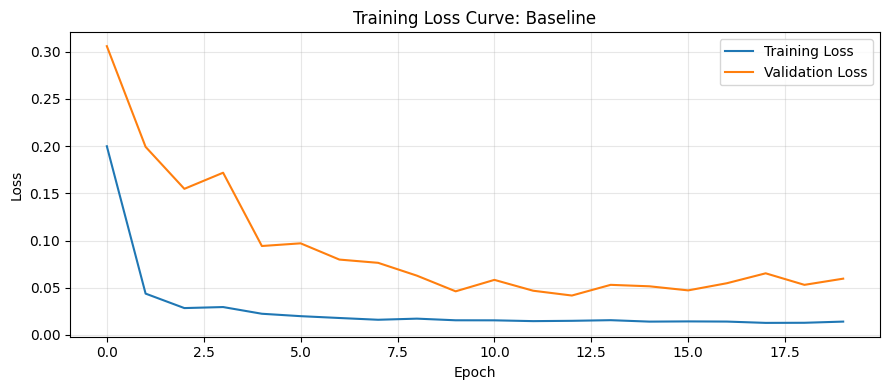

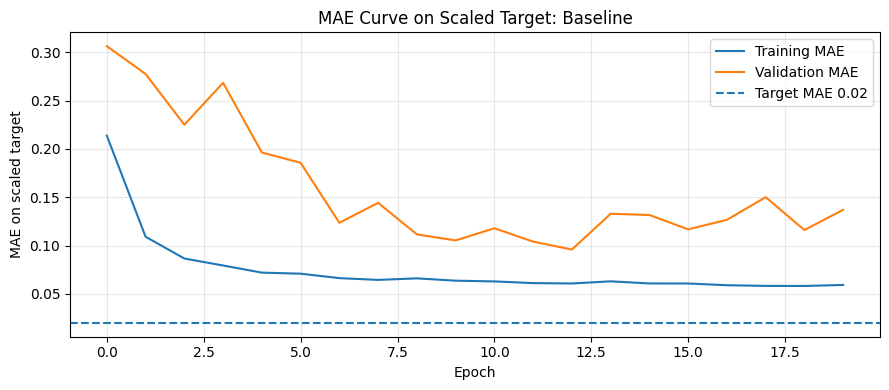

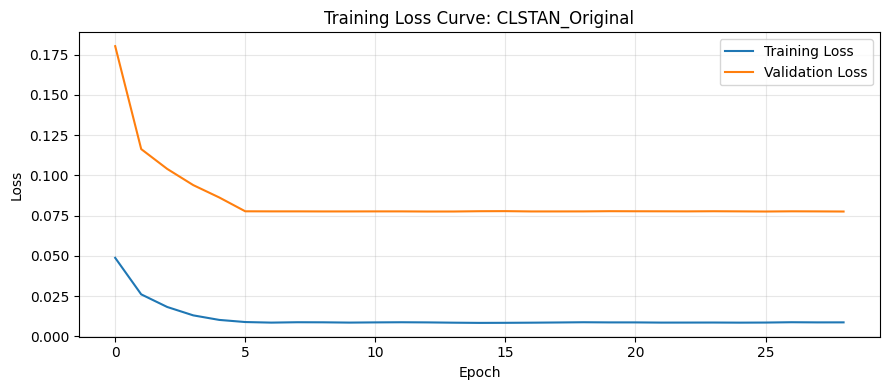

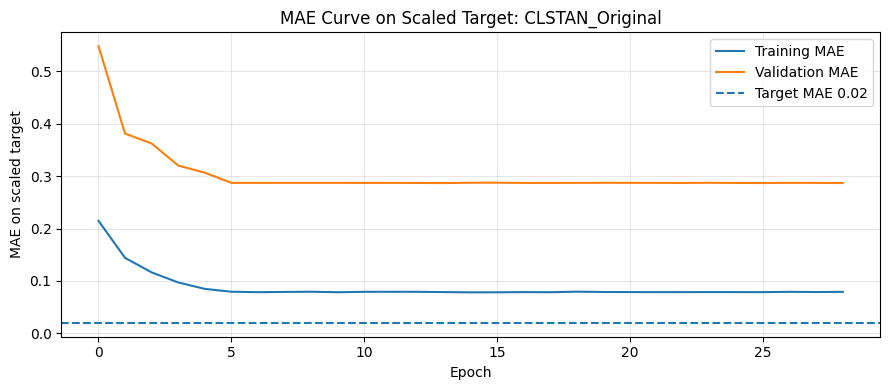

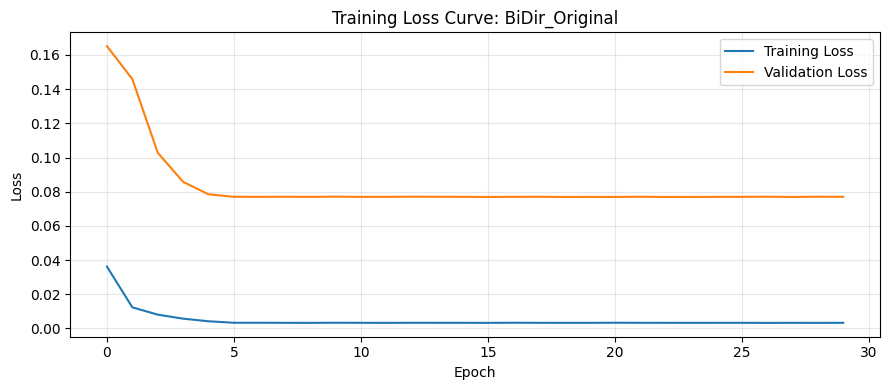

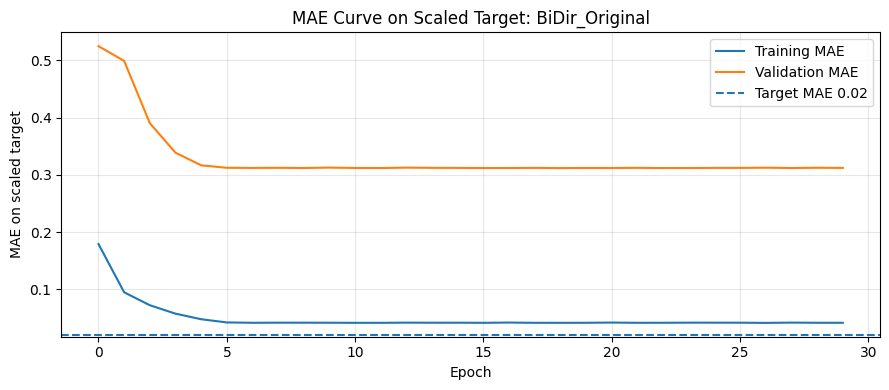

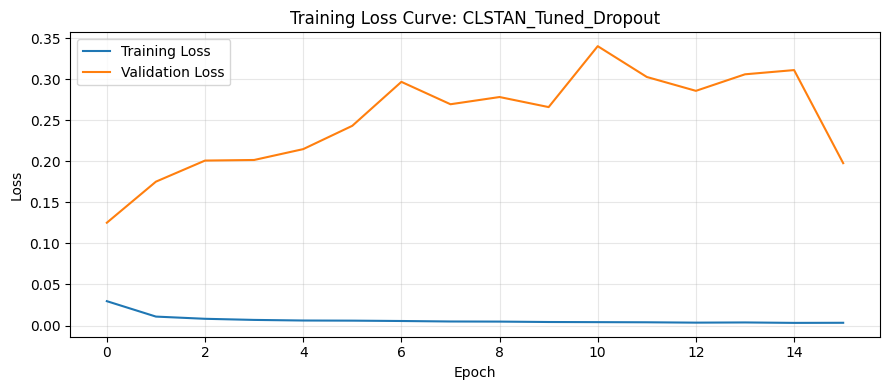

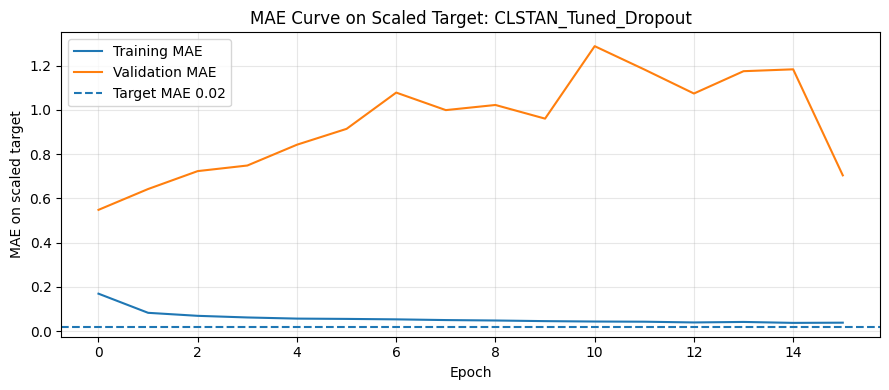

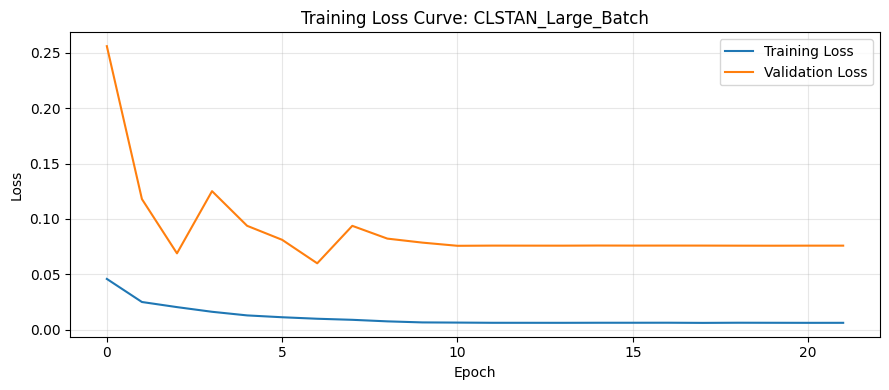

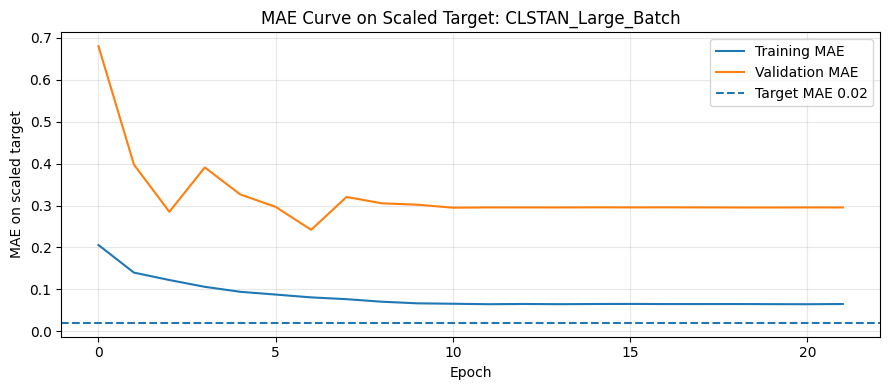

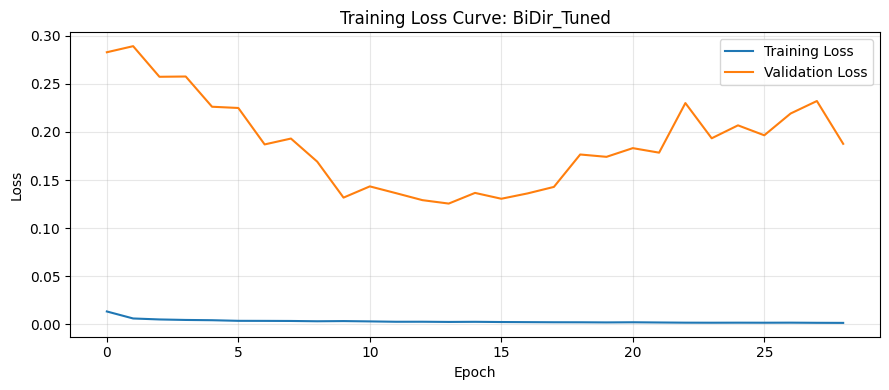

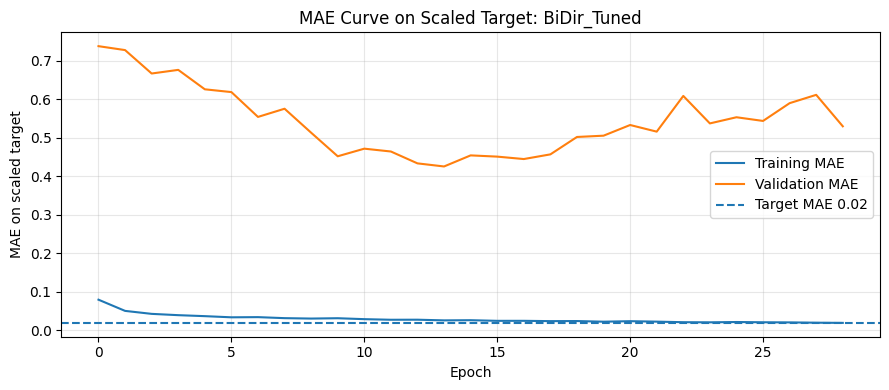

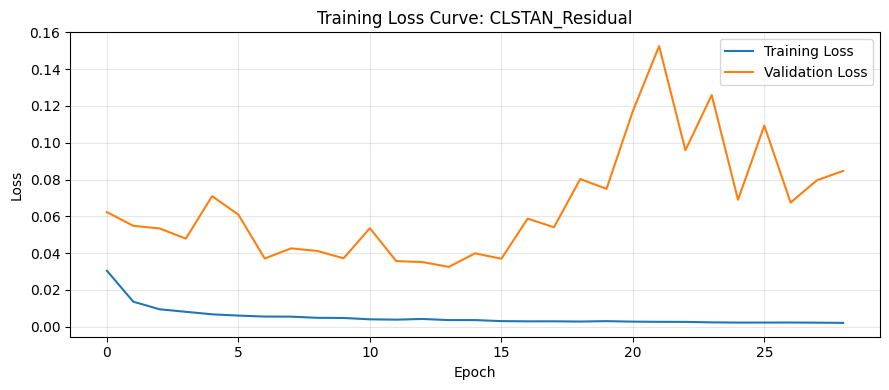

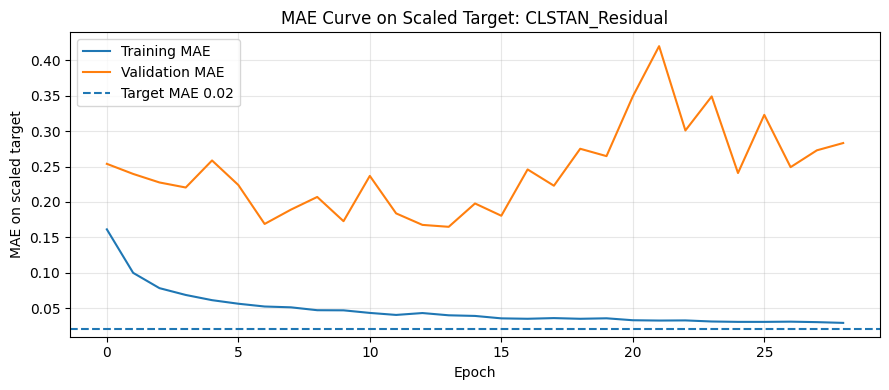

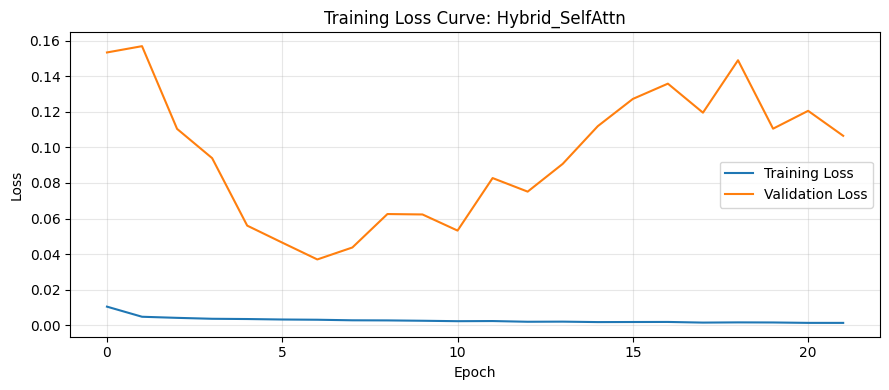

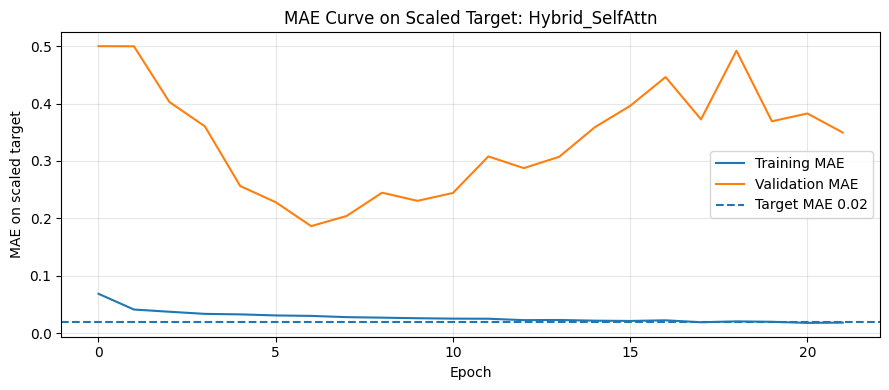

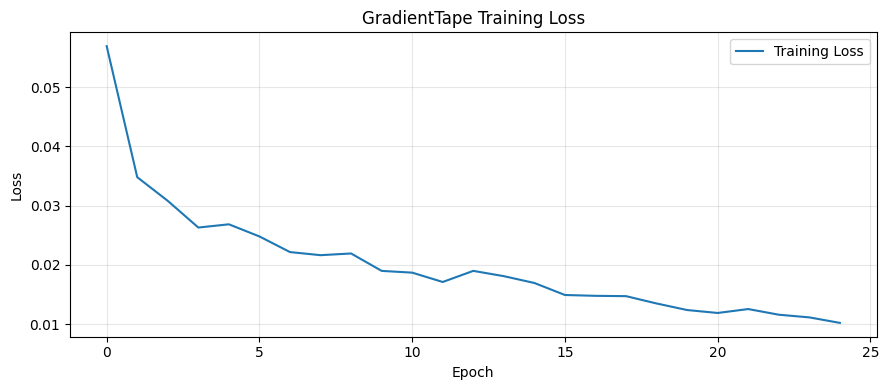

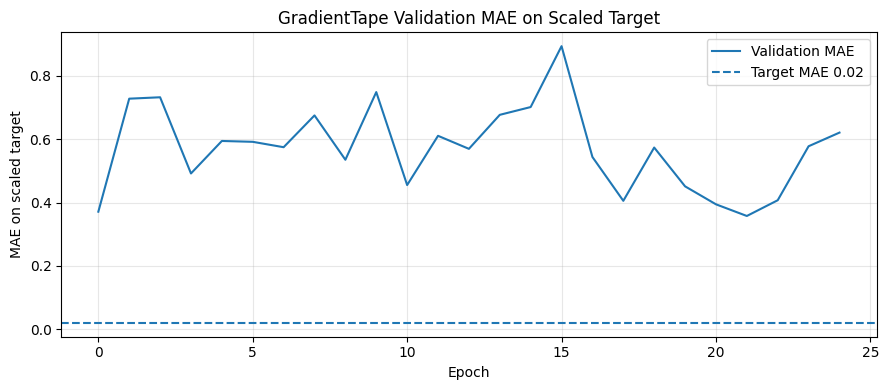

In [ ]:
# -----------------------------------------------------------------------------
# 19. Training Curves Visualization
# -----------------------------------------------------------------------------
# Kurva training dan validation membantu mengevaluasi apakah model mengalami
# underfitting, overfitting, atau sudah konvergen secara wajar.

# Plot training curves for standard experiments.
standard_names = [name for name, hist in histories.items() if hasattr(hist, 'history')]
for model_name in standard_names:
    hist = histories[model_name]
    plt.figure(figsize=(9, 4))
    plt.plot(hist.history.get('loss', []), label='Training Loss')
    plt.plot(hist.history.get('val_loss', []), label='Validation Loss')
    plt.title(f'Training Loss Curve: {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'training_loss_{model_name}.png', dpi=120)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(hist.history.get('mae', []), label='Training MAE')
    plt.plot(hist.history.get('val_mae', []), label='Validation MAE')
    plt.axhline(0.02, linestyle='--', label='Target MAE 0.02')
    plt.title(f'MAE Curve on Scaled Target: {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('MAE on scaled target')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'training_mae_{model_name}.png', dpi=120)
    plt.show()

# GradientTape curves.
plt.figure(figsize=(9, 4))
plt.plot(tape_history['loss'], label='Training Loss')
plt.title('GradientTape Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradtape_training_loss.png', dpi=120)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(tape_history['val_mae'], label='Validation MAE')
plt.axhline(0.02, linestyle='--', label='Target MAE 0.02')
plt.title('GradientTape Validation MAE on Scaled Target')
plt.xlabel('Epoch')
plt.ylabel('MAE on scaled target')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradtape_validation_mae.png', dpi=120)
plt.show()


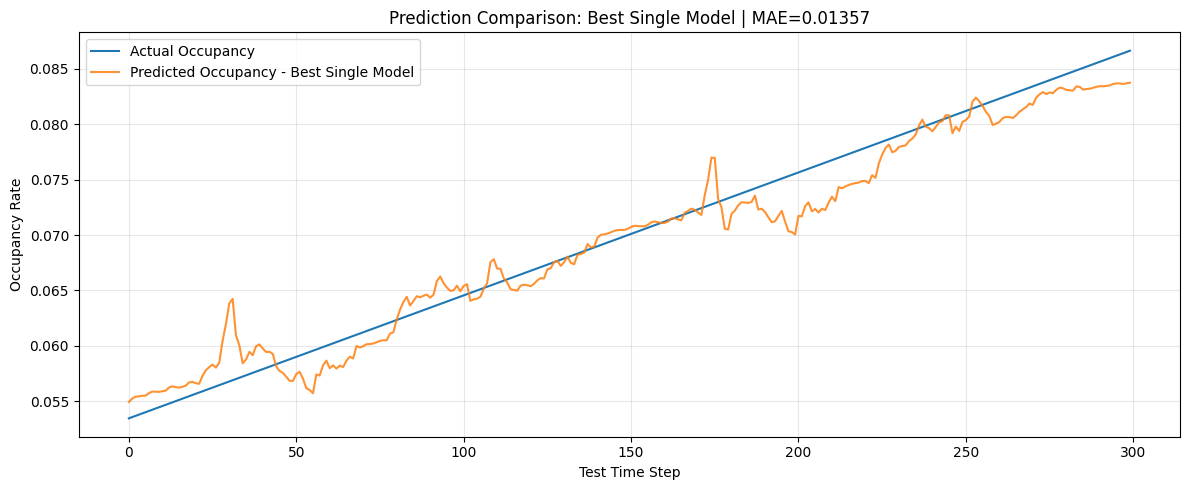

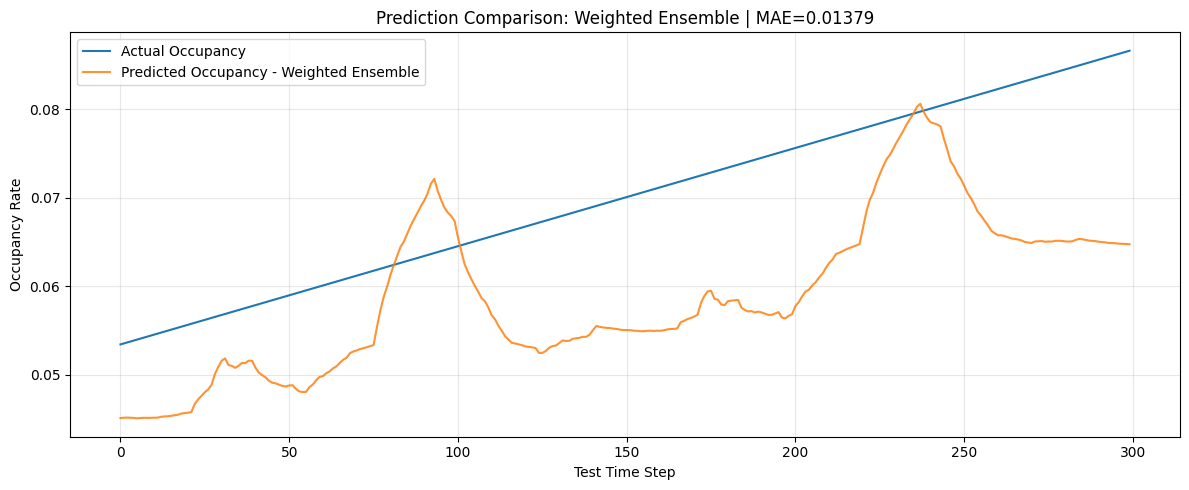

In [ ]:
# -----------------------------------------------------------------------------
# 19. Prediction Visualization
# -----------------------------------------------------------------------------
# Plot prediksi dibandingkan aktual digunakan sebagai pemeriksaan visual.
# Evaluasi numerik tetap menjadi acuan utama, tetapi plot membantu melihat pola
# kesalahan pada periode waktu tertentu.

n_plot = min(300, len(y_test_raw))
plot_predictions = {
    'Best Single Model': test_preds_dict[best_single_name],
    'Weighted Ensemble': yp_ens
}

for name, pred in plot_predictions.items():
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_raw[:n_plot], label='Actual Occupancy')
    plt.plot(pred[:n_plot], label=f'Predicted Occupancy - {name}', alpha=0.85)
    mae_value = mean_absolute_error(y_test_raw, pred)
    plt.title(f'Prediction Comparison: {name} | MAE={mae_value:.5f}')
    plt.xlabel('Test Time Step')
    plt.ylabel('Occupancy Rate')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'prediction_comparison_{name.replace(" ", "_").lower()}.png', dpi=120)
    plt.show()


## 4.4 Optional FastAPI Export

Bagian ini menyiapkan file API sederhana. Jalankan hanya setelah model, scaler, dan daftar fitur selesai disimpan.


In [ ]:
%%writefile /content/smartpark_api.py
# -----------------------------------------------------------------------------
# 20. Optional FastAPI Export
# -----------------------------------------------------------------------------
# File API ini bersifat opsional untuk demonstrasi deployment.
# Endpoint /predict menggunakan model dan scaler yang sudah diekspor dari notebook.
# Struktur fitur pada API harus tetap konsisten dengan pipeline training.

import pickle
import datetime as dt
from pathlib import Path
from typing import List, Optional

import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field

OUTPUT_DIR = Path('/content/smartpark_outputs')
WINDOW_SIZE = 18

with open(OUTPUT_DIR / 'scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)
with open(OUTPUT_DIR / 'scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)
with open(OUTPUT_DIR / 'feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

N_FEATURES = len(FEATURE_COLS)
weather_map = {'SUNNY': 0, 'OVERCAST': 1, 'RAINY': 2, 'UNKNOWN': 0, 'S': 0, 'C': 1, 'R': 2}

app = FastAPI(title='SmartPark Occupancy Forecasting API', version='1.0')
app.add_middleware(CORSMiddleware, allow_origins=['*'], allow_credentials=True, allow_methods=['*'], allow_headers=['*'])

_models = {}

def load_model():
    import tensorflow as tf
    if 'model' not in _models:
        model_path = OUTPUT_DIR / 'CLSTAN_Original.keras'
        if not model_path.exists():
            model_path = OUTPUT_DIR / 'Baseline.keras'
        if not model_path.exists():
            raise FileNotFoundError('Model file is not available in OUTPUT_DIR.')
        _models['model'] = tf.keras.models.load_model(str(model_path), compile=False)
    return _models['model']

class Observation(BaseModel):
    occupancy_rate: float = Field(..., ge=0, le=1)
    hour: int = Field(..., ge=0, le=23)
    day_of_week: int = Field(..., ge=0, le=6)
    weather: Optional[str] = 'UNKNOWN'

class PredictRequest(BaseModel):
    observations: List[Observation]


def build_features(observations: List[dict]) -> pd.DataFrame:
    data = pd.DataFrame(observations)
    data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
    data['weather_encoded'] = data['weather'].map(weather_map).fillna(0).astype(int)
    data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
    data['dow_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
    data['dow_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)
    data['is_morning_peak'] = data['hour'].between(8, 11).astype(int)
    data['is_evening_peak'] = data['hour'].between(16, 19).astype(int)
    data['is_rush_hour'] = data['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)

    for lag in [1, 2, 3, 6, 12, 24, 48]:
        data[f'lag_{lag}'] = data['occupancy_rate'].shift(lag)
    for window in [3, 6, 12, 24, 48]:
        data[f'roll_mean_{window}'] = data['occupancy_rate'].rolling(window, min_periods=1).mean()
        data[f'roll_std_{window}'] = data['occupancy_rate'].rolling(window, min_periods=1).std().fillna(0)

    data['momentum'] = data['occupancy_rate'].diff().fillna(0)
    data['acceleration'] = data['momentum'].diff().fillna(0)
    data['ema_01'] = data['occupancy_rate'].ewm(alpha=0.1).mean()
    data['ema_03'] = data['occupancy_rate'].ewm(alpha=0.3).mean()
    data[FEATURE_COLS] = data[FEATURE_COLS].bfill().ffill().fillna(0)
    return data

@app.get('/health')
def health():
    return {'status': 'ok', 'timestamp': dt.datetime.now().isoformat()}

@app.post('/predict')
def predict(request: PredictRequest):
    if len(request.observations) < WINDOW_SIZE:
        raise HTTPException(status_code=400, detail=f'Minimum {WINDOW_SIZE} observations are required.')

    obs = [item.dict() for item in request.observations]
    features = build_features(obs).tail(WINDOW_SIZE)
    X = scaler_X.transform(features[FEATURE_COLS]).reshape(1, WINDOW_SIZE, N_FEATURES).astype(np.float32)

    model = load_model()
    pred_scaled = model.predict(X, verbose=0).flatten()[0]
    pred_raw = scaler_y.inverse_transform(np.array([[pred_scaled]])).flatten()[0]
    pred_raw = float(np.clip(pred_raw, 0, 1))

    return {
        'predicted_occupancy_30min': round(pred_raw, 4),
        'predicted_pct': f'{pred_raw * 100:.1f}%',
        'timestamp': dt.datetime.now().isoformat()
    }

Writing /content/smartpark_api.py


## 4.5 Interpretasi Akhir yang Diharapkan

Pada akhir notebook, pembaca diharapkan dapat melihat tiga lapisan kesimpulan:

1. **Kesimpulan Data Science**: pola occupancy berdasarkan waktu, cuaca, hari, dinamika historis, kualitas data, serta hasil offline backtesting dan block bootstrapping.
2. **Kesimpulan Pemodelan**: performa setiap model, model terbaik, weighted ensemble, serta kesesuaian hasil dengan target MAE dan akurasi.
3. **Kesimpulan Implementasi**: kesiapan artefak model, scaler, feature list, contoh inference, dan endpoint API untuk integrasi aplikasi.

Kesimpulan final sebaiknya selalu menyebutkan metrik pada skala asli `occupancy_rate`, karena metrik tersebut paling mudah diterjemahkan ke keputusan operasional.

## 4.6 Catatan untuk Pembaca Praktisi

Notebook ini perlu dibaca sebagai pipeline yang saling berkesinambungan:

1. **Data Science** menjelaskan sumber data, proses pembersihan, pola okupansi, dan rancangan fitur.
2. **Pemodelan Prediktif** menggunakan fitur tersebut untuk membangun model forecasting 30 menit ke depan.
3. **Evaluasi** membandingkan model terhadap baseline agar klaim performa dapat dibuktikan secara objektif.
4. **Deployment Preparation** menyiapkan artefak agar pipeline dapat diintegrasikan ke aplikasi.

Dengan struktur ini, laporan tidak hanya menunjukkan bahwa model dapat dilatih, tetapi juga menunjukkan alasan data, metode evaluasi, dan kesiapan implementasinya.

## 4.7 Model Export dan Final Summary

Bagian ini menyimpan artefak utama yang dibutuhkan untuk deployment dan inference, termasuk model terbaik, scaler, daftar fitur, tabel evaluasi, ringkasan A/B testing, dan ringkasan bootstrap.


In [ ]:
# -----------------------------------------------------------------------------
# 21. Model Export and Final Summary
# -----------------------------------------------------------------------------
# Cell ini menyimpan artefak utama yang dibutuhkan untuk deployment dan inference:
# - model terbaik;
# - scaler_X;
# - scaler_y;
# - daftar fitur;
# - tabel evaluasi;
# - ringkasan A/B testing dan bootstrap.

# Save the best single model in a standardized name for deployment.
best_single_name = min(validation_maes, key=validation_maes.get)
best_single_path = saved_models[best_single_name]

best_model = keras.models.load_model(
    best_single_path,
    custom_objects={'TemporalAttention': TemporalAttention, 'loss': weighted_huber_loss()},
    compile=False
)
best_model.save(OUTPUT_DIR / 'best_model.keras')

summary = {
    'dataset': 'CNRPark+EXT CSV',
    'forecast_horizon_minutes': TARGET_HORIZON * 10,
    'window_size': WINDOW_SIZE,
    'number_of_features': N_FEATURES,
    'best_model_by_test_mae': str(results_df.iloc[0]['Model']),
    'best_test_mae_original_scale': float(results_df.iloc[0]['MAE']),
    'best_test_rmse_original_scale': float(results_df.iloc[0]['RMSE']),
    'best_test_r2': float(results_df.iloc[0]['R2']),
    'best_accuracy_within_0.05_pct': float(results_df.iloc[0]['Accuracy_within_0.05_pct']),
    'best_single_model_by_validation_mae': best_single_name,
    'evaluation_note': 'Final metrics are computed after inverse_transform to the original occupancy scale.',
    'ab_testing_owner': 'Data Science',
    'ab_testing_method': 'Offline historical backtesting with naive persistence baseline',
    'bootstrap_method': 'Block bootstrap on paired error difference'
}

with open(OUTPUT_DIR / 'run_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Final project summary')
for key, value in summary.items():
    print(f'{key}: {value}')

print('\nGenerated artifacts:')
for path in sorted(OUTPUT_DIR.glob('*')):
    print(path)


Final project summary
dataset: CNRPark+EXT CSV
forecast_horizon_minutes: 30
window_size: 18
number_of_features: 27
best_model_by_test_mae: Hybrid_SelfAttn
best_test_mae_original_scale: 0.013392548219642648
best_test_rmse_original_scale: 0.03409381167942513
best_test_r2: 0.9812946148585661
best_accuracy_within_0.05_pct: 93.65440264572136
best_single_model_by_validation_mae: Baseline
evaluation_note: Final metrics are computed after inverse_transform to the original occupancy scale.
ab_testing_owner: Data Science
ab_testing_method: Offline historical backtesting with naive persistence baseline
bootstrap_method: Block bootstrap on paired error difference

Generated artifacts:
/content/smartpark_outputs/Baseline.keras
/content/smartpark_outputs/BiDir_Original.keras
/content/smartpark_outputs/BiDir_Tuned.keras
/content/smartpark_outputs/CLSTAN_Large_Batch.keras
/content/smartpark_outputs/CLSTAN_Original.keras
/content/smartpark_outputs/CLSTAN_Residual.keras
/content/smartpark_outputs/CLSTAN

## Ringkasan Interpretasi Eksekusi

Berdasarkan eksekusi validasi cepat, beberapa kesimpulan awal yang layak dicatat dalam laporan adalah:

1. Proyek ini tepat diposisikan sebagai **time-series forecasting occupancy rate**, bukan klasifikasi 0/1. Nilai 0/1 hanya berasal dari status slot pada data mentah.
2. Data memiliki autokorelasi sangat kuat, sehingga fitur lag dan rolling statistics relevan.
3. Naive persistence baseline sangat kompetitif untuk horizon 30 menit. Ini membuat A/B testing berbasis backtesting menjadi bagian penting dari Data Science.
4. Quick run neural network belum mengalahkan naive baseline, tetapi hasil ini belum final karena konfigurasi training penuh belum dijalankan di GPU.
5. Untuk laporan akhir, gunakan metrik utama pada skala asli `occupancy_rate`: MAE, RMSE, R², dan accuracy within ±0.05 setelah inverse transform.


In [ ]:
from pathlib import Path
import shutil
import os

# Folder sumber di Colab
SOURCE_DIR = Path("/content")

# Folder tujuan di Google Drive
DRIVE_DIR = Path("/content/drive/MyDrive/SmartPark_Capstone_Final")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

# Nama ZIP final
ZIP_NAME = "SmartPark_Capstone_Final_Package"
ZIP_PATH = DRIVE_DIR / f"{ZIP_NAME}.zip"

print("Folder sumber:", SOURCE_DIR)
print("Folder tujuan Drive:", DRIVE_DIR)
print("ZIP akan disimpan di:", ZIP_PATH)

Folder sumber: /content
Folder tujuan Drive: /content/drive/MyDrive/SmartPark_Capstone_Final
ZIP akan disimpan di: /content/drive/MyDrive/SmartPark_Capstone_Final/SmartPark_Capstone_Final_Package.zip


In [ ]:
SOURCE_DIR = Path("/content/SmartPark_Capstone_Final_Package")

In [ ]:
from pathlib import Path
import shutil
import os

# Assume SOURCE_DIR, DRIVE_DIR, ZIP_PATH, ZIP_NAME are already defined from previous cells.
# For example, from kernel state, SOURCE_DIR is '/content/SmartPark_Capstone_Final_Package'

# Ensure the intended SOURCE_DIR exists.
# This was missing in the original sequence, leading to FileNotFoundError.
if not SOURCE_DIR.exists():
    SOURCE_DIR.mkdir(parents=True, exist_ok=True)

# Copy the actual generated outputs into the SOURCE_DIR.
# The `smartpark_outputs` folder and `smartpark_api.py` file are the main artifacts.
outputs_to_copy = [
    Path("/content/smartpark_outputs"),
    Path("/content/smartpark_api.py")
]

for item_path in outputs_to_copy:
    if item_path.exists():
        if item_path.is_dir():
            shutil.copytree(item_path, SOURCE_DIR / item_path.name, dirs_exist_ok=True)
        else:
            shutil.copy(item_path, SOURCE_DIR / item_path.name)
    else:
        print(f"Warning: {item_path} not found. Skipping copy.")


# Hapus ZIP lama jika sudah ada
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# Buat ZIP sementara tanpa ekstensi .zip
zip_base = DRIVE_DIR / ZIP_NAME

# Buat archive ZIP dari folder sumber
shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=str(SOURCE_DIR)
)

print("ZIP berhasil dibuat dan disimpan ke Google Drive:")
print(ZIP_PATH)

ZIP berhasil dibuat dan disimpan ke Google Drive:
/content/drive/MyDrive/SmartPark_Capstone_Final/SmartPark_Capstone_Final_Package.zip
